# Introduction to Time‑Series Data

A time series is a sequence of observations recorded over time. The defining characteristic of time‑series data is that the order of observations matters, because values often depend on previous values.

Examples:


*   Stock prices recorded every minute

*   Daily temperature measurements

*   Hourly electricity demand
*   Sensor readings from machines








Unlike many other datasets, time is an explicit variable and observations are typically indexed by timestamps.

Typical structure of time-series data:

| Date | Value |
|-----|------|
| 2023‑01‑01 | 120 |
| 2023‑01‑02 | 125 |
| 2023‑01‑03 | 119 |

In Python we usually represent time-series using **pandas DataFrames with a datetime index**.

---

## 2. Types of Data Structures

In data science we usually work with three main dataset structures:

### 1. Cross‑Sectional Data

Cross‑sectional data contains observations collected **at a single point in time** across many entities.

Example: Income of individuals in 2024.

| Person | Income |
|------|------|
| A | 52000 |
| B | 61000 |
| C | 47000 |

Characteristics:

- No time dimension
- Each row represents a different entity
- Used in regression and statistical analysis


In [1]:

import pandas as pd

cross_sectional = pd.DataFrame({
    "person": ["A", "B", "C", "D"],
    "income": [52000, 61000, 47000, 55000]
})

cross_sectional


,person,income
0,A,52000
1,B,61000
2,C,47000
3,D,55000




### 2. Time‑Series Data

Time‑series data records **one variable over multiple time periods**.

Example: Daily temperature.

| Date | Temperature |
|-----|------|
| 2024‑01‑01 | 12 |
| 2024‑01‑02 | 11 |
| 2024‑01‑03 | 14 |


In [2]:

dates = pd.date_range(start="2024-01-01", periods=5)

time_series = pd.DataFrame({
    "date": dates,
    "temperature": [12, 11, 14, 13, 15]
})

time_series


,date,temperature
0,2024-01-01,12
1,2024-01-02,11
2,2024-01-03,14
3,2024-01-04,13
4,2024-01-05,15




### 3. Panel (Longitudinal) Data

Panel data combines **cross‑sectional and time‑series dimensions**.

It tracks **multiple entities over time**.

Example: GDP for several countries across years.

| Country | Year | GDP |
|-------|------|------|
| USA | 2020 | 21000 |
| USA | 2021 | 23000 |
| UK | 2020 | 3000 |
| UK | 2021 | 3200 |

Example in Python:



In [3]:

panel_data = pd.DataFrame({
    "country": ["USA","USA","UK","UK"],
    "year": [2020,2021,2020,2021],
    "gdp": [21000,23000,3000,3200]
})

panel_data


,country,year,gdp
0,USA,2020,21000
1,USA,2021,23000
2,UK,2020,3000
3,UK,2021,3200



### Summary

| Data Type | Time Dimension | Multiple Entities |
|------|------|------|
| Cross‑sectional | ❌ | ✅ |
| Time‑series | ✅ | ❌ |
| Panel | ✅ | ✅ |





#  Initial Exploration & Visualization



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

path = "data/daily-min-temperatures.csv"
df = pd.read_csv(path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

df.head()


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


Basic numeric summaries:



In [5]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000



Time‑indexed summaries:



In [6]:
df["Temp"].resample("ME").mean().head()

Date
1981-01-31    17.712903
1981-02-28    17.678571
1981-03-31    13.500000
1981-04-30    12.356667
1981-05-31     9.490323
Freq: ME, Name: Temp, dtype: float64

Distribution analysis:

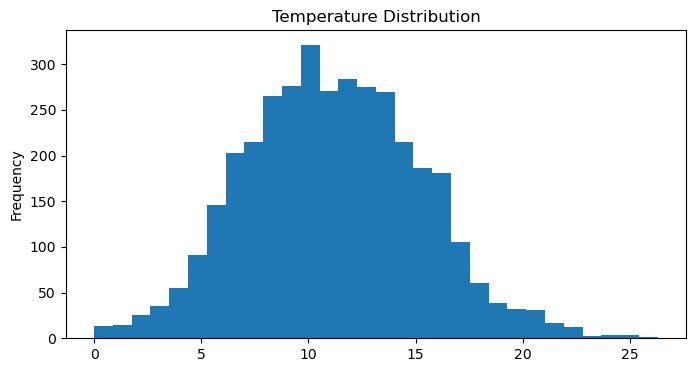

In [7]:
df["Temp"].plot(kind="hist", bins=30, figsize=(8,4), title="Temperature Distribution")
plt.show()

Autocorrelation visualization:

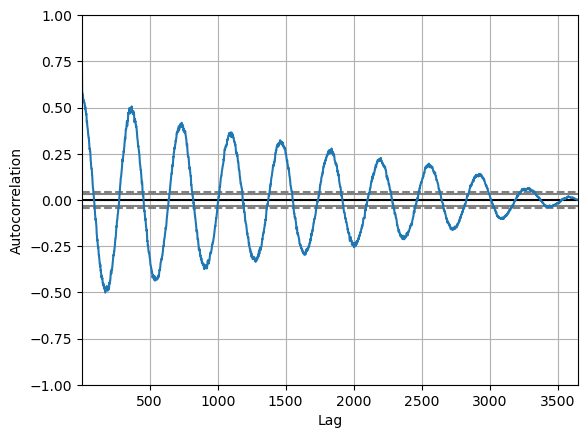

In [8]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df["Temp"])
plt.show()

## Simple Time‑Series Line Plot

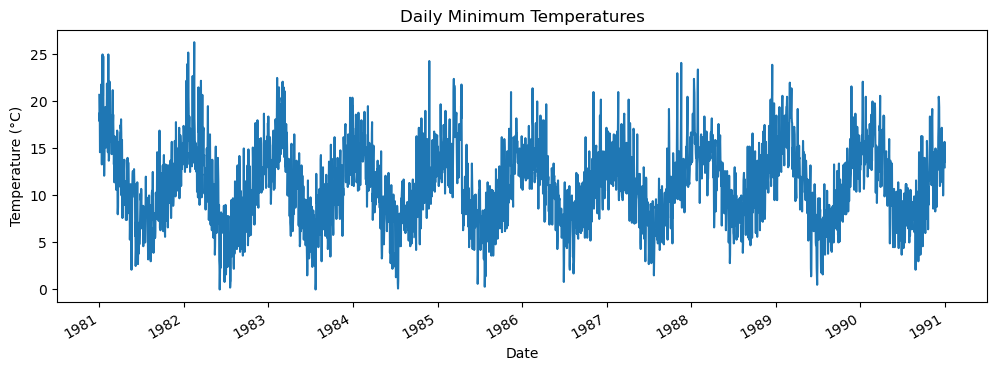

In [9]:
df["Temp"].plot(figsize=(12,4), title="Daily Minimum Temperatures")
plt.ylabel("Temperature (°C)")
plt.show()


Zoom into a shorter period:

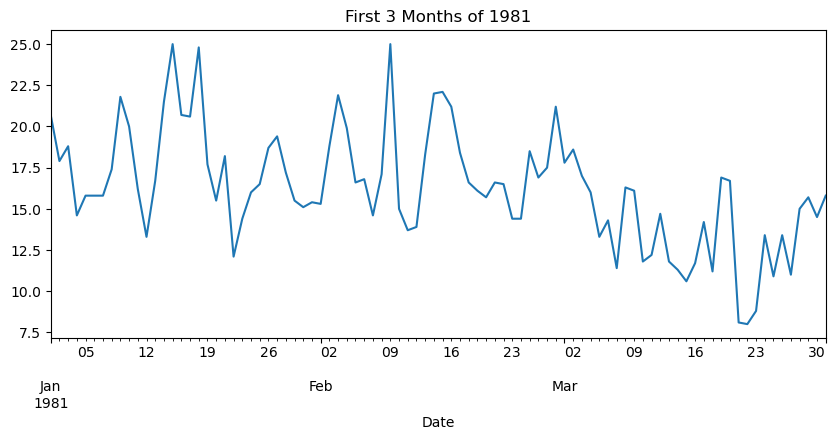

In [10]:
df["Temp"]["1981-01":"1981-03"].plot(figsize=(10,4), title="First 3 Months of 1981")
plt.show()

## Seasonal Plots (Daily, Monthly, Yearly)

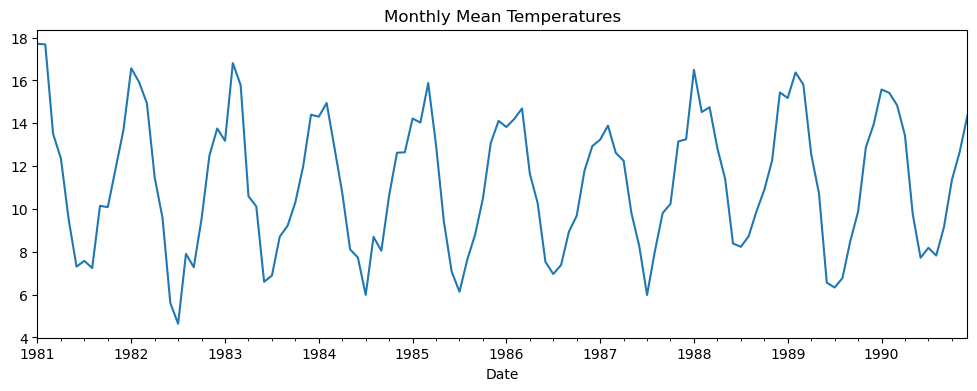

In [11]:
df["Temp"].resample("ME").mean().plot(figsize=(12,4), title="Monthly Mean Temperatures")
plt.show()

Yearly trend:

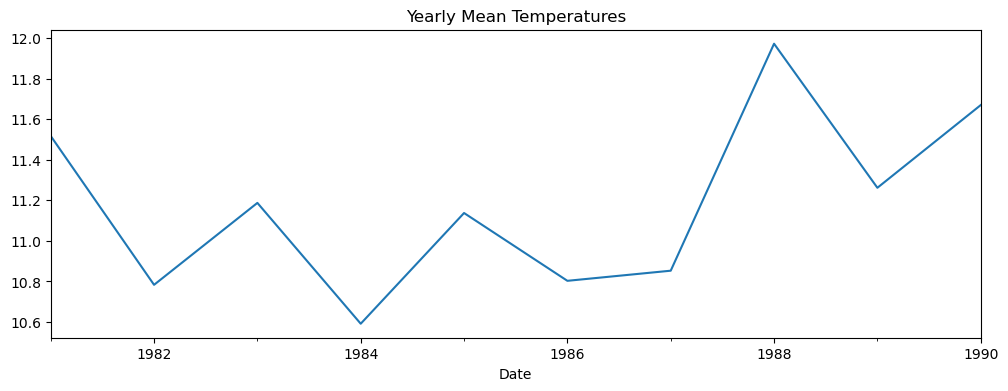

In [12]:
df["Temp"].resample("YE").mean().plot(figsize=(12,4), title="Yearly Mean Temperatures")
plt.show()

Seasonality by month (groupby visualization)

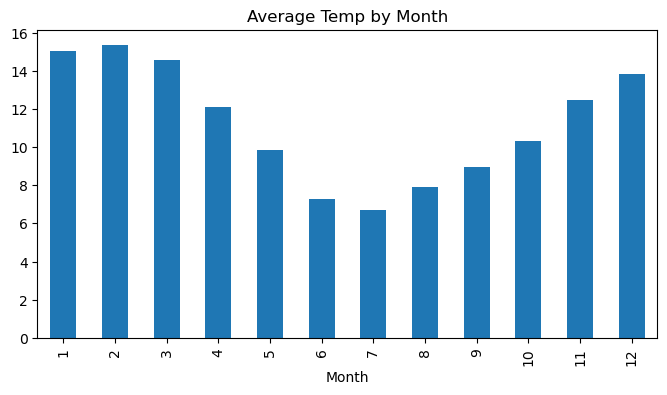

In [13]:
df["Month"] = df.index.month
df.groupby("Month")["Temp"].mean().plot(kind="bar", figsize=(8,4), title="Average Temp by Month")
plt.show()

Seasonality by year/month heatmap

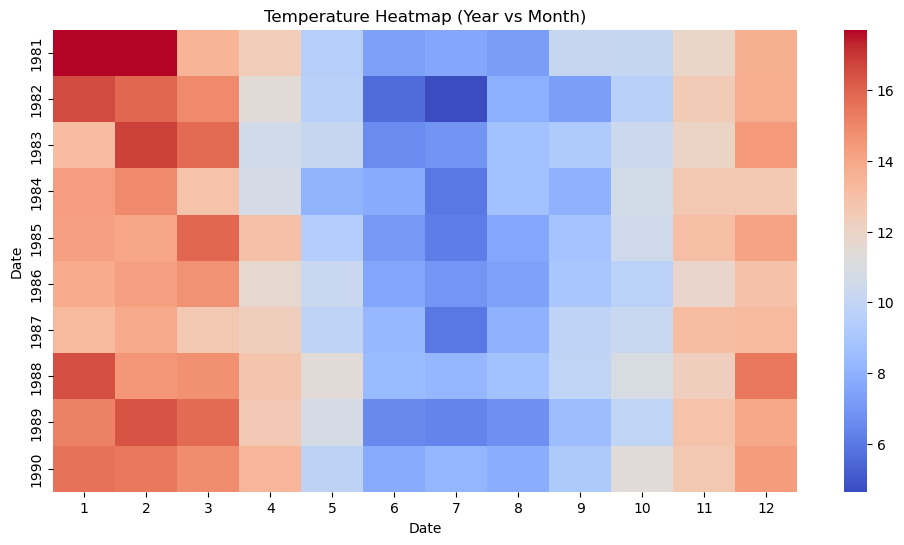

In [14]:
import seaborn as sns

pivot = df.pivot_table(values="Temp", index=df.index.year, columns=df.index.month)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Temperature Heatmap (Year vs Month)")
plt.show()

## Rolling Mean / Median Visualization

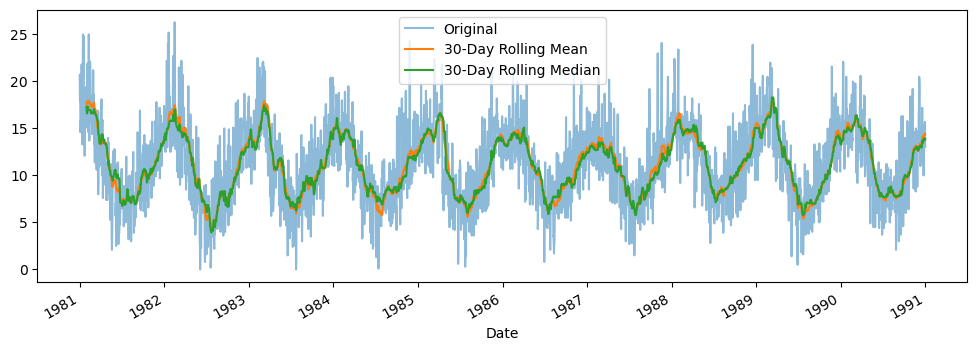

In [15]:
df["Temp"].plot(figsize=(12,4), alpha=0.5, label="Original")

df["Temp"].rolling(30).mean().plot(label="30‑Day Rolling Mean")
df["Temp"].rolling(30).median().plot(label="30‑Day Rolling Median")

plt.legend()
plt.show()


Smooth longer windows:

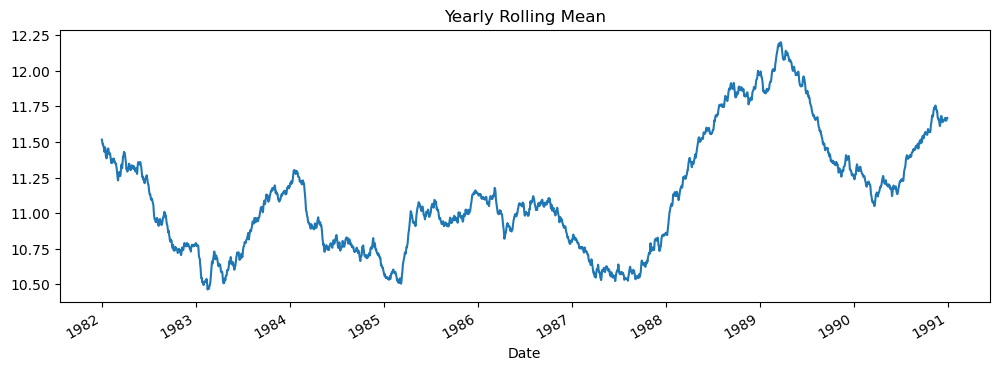

In [16]:
df["Temp"].rolling(365).mean().plot(figsize=(12,4), title="Yearly Rolling Mean")
plt.show()


## Outlier Identification

Method 1: Z‑ScoresA
 Z‑score measures how many standard deviations a data point is from the mean of the series.
 Interpretation:

• z = 0 → value is exactly at the mean

• z = 1 → value is 1 standard deviation above the mean

• z = −2 → value is 2 standard deviations below the mean

A common rule:

• |z| > 3 → likely an outlier

Because in normally‑distributed data, values beyond 3 standard deviations are extremely rare (≈0.3%).

Why Z‑Scores Work for Time Series
Z‑scores give a quick global view of outliers across the entire dataset.

However:

• they assume the distribution is roughly stable

• they do not adapt to local seasonal patterns

• large seasonal swings may look like outliers when they are normal

Therefore Z‑scores are good for:

• simple datasets

• data with stable variance

• first‑pass detection

But not ideal for strongly seasonal or drifting dat

In [17]:
import numpy as np

df["z"] = (df["Temp"] - df["Temp"].mean()) / df["Temp"].std()
outliers = df[df["z"].abs() > 3]

outliers.head()


,Temp,Month,z
Date,,,
1981-01-15,25.0,1,3.394597
1981-01-18,24.8,1,3.345479
1981-02-09,25.0,2,3.394597
1982-01-17,24.0,1,3.149008
1982-01-20,25.2,1,3.443715


Plot outliers


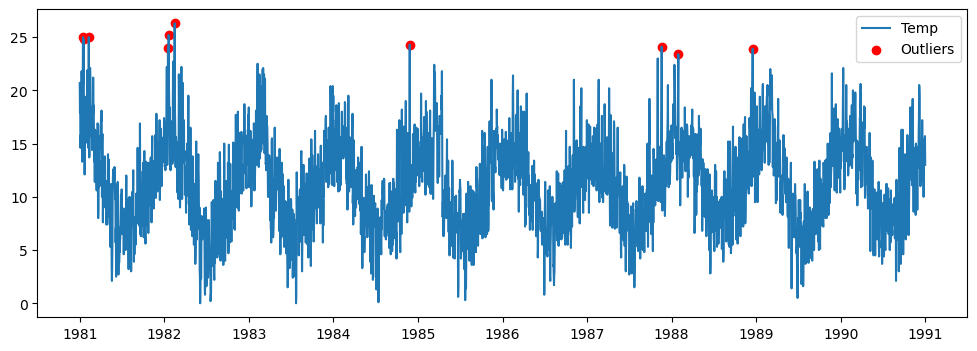

In [18]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["Temp"], label="Temp")
plt.scatter(outliers.index, outliers["Temp"], color="red", label="Outliers")
plt.legend()
plt.show()


What is IQR?

IQR is the inner range of the data:


IQR = Q3 − Q1


Where:

• Q1 = 25th percentile

• Q3 = 75th percentile

The IQR model considers points outside this range as outliers:



Lower bound = Q1 − 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

What Does “Rolling IQR” Mean?

In time series, we compute IQR for each window of time (e.g., last 30 days):

For each point t:

Look at the previous 30 days
Compute Q1, Q3, and IQR for that window
Flag point t as an outlier if:


value(t) < Q1 - 1.5 × IQR

value(t) > Q3 + 1.5 × IQR

Why Rolling IQR Works Better for Time Series

Rolling IQR is adaptive:

• it adjusts for local seasonal patterns

• it respects changing variance

• it detects sudden local spikes/drops

• it avoids classifying seasonal peaks as outliers

Rolling IQR is ideal when:

• the series has strong seasonality (temperature, sales, energy load)

• the mean/variance drift over time

• you need local anomaly detection rather than global

In [19]:
roll = df["Temp"].rolling(30)
q1 = roll.quantile(0.25)
q3 = roll.quantile(0.75)
iqr = q3 - q1

mask = (df["Temp"] < (q1 - 1.5*iqr)) | (df["Temp"] > (q3 + 1.5*iqr))
outliers_iqr = df[mask]

outliers_iqr.head()


,Temp,Month,z
Date,,,
1981-05-19,3.2,5,-1.959252
1981-05-20,2.1,5,-2.229400
1982-01-12,22.2,1,2.706947
1982-01-17,24.0,1,3.149008
1982-01-19,19.7,1,2.092973


## Missing‑Value Patterns

Simulate missing values (the dataset has none):

In [20]:
df_missing = df.copy()
df_missing.iloc[100:120] = None
df_missing.iloc[500] = None
df_missing.iloc[1000:1010] = None

df_missing.isna().sum()


Temp     31
Month    31
z        31
dtype: int64

Visual missingness pattern

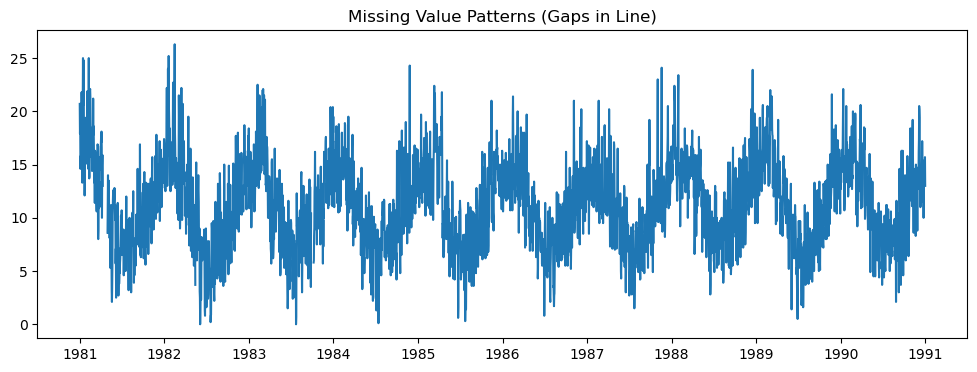

In [21]:
plt.figure(figsize=(12,4))
plt.plot(df_missing.index, df_missing["Temp"])
plt.title("Missing Value Patterns (Gaps in Line)")
plt.show()


Heatmap of missing data


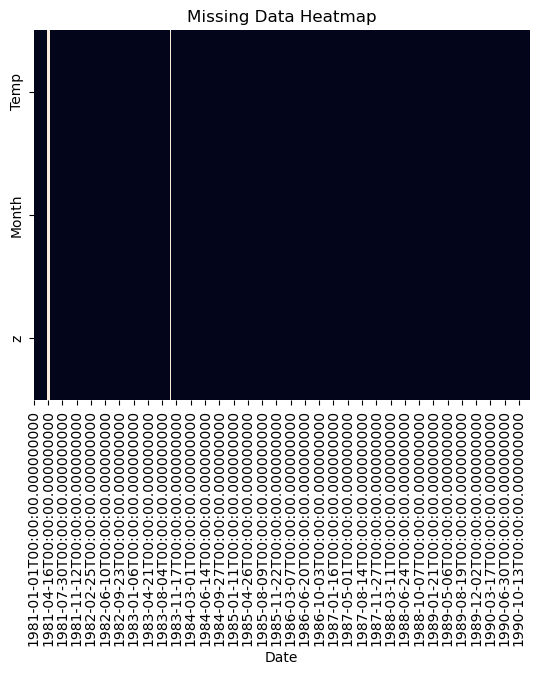

In [27]:
sns.heatmap(df_missing.isna().T, cbar=False)      
plt.title("Missing Data Heatmap")      
plt.show()

### Exercise 1 — Compute Yearly Volatility and Explain Anomalies

1. Compute the **standard deviation of temperature** for each year.  
2. Identify the **three most volatile years**.  
3. Create a plot comparing those years side‑by‑side.  
4. Write explanations for why these years might show higher volatility (hint: seasonal cycles, shifts).



1.Yearly Standard Deviation

In [28]:
yearly_volatility = df["Temp"].resample("YE").std()

yearly_volatility

Date
1981-12-31    4.337430
1982-12-31    4.806858
1983-12-31    4.187325
1984-12-31    3.733946
1985-12-31    4.138998
1986-12-31    3.610910
1987-12-31    3.626849
1988-12-31    3.748566
1989-12-31    4.333539
1990-12-31    3.861600
Freq: YE-DEC, Name: Temp, dtype: float64

2.three most volatile years

In [29]:
top_3_volatile = yearly_volatility.sort_values(ascending=False).head(3)

print(top_3_volatile)

Date
1982-12-31    4.806858
1981-12-31    4.337430
1989-12-31    4.333539
Name: Temp, dtype: float64


3.Plot the Most Volatile Years

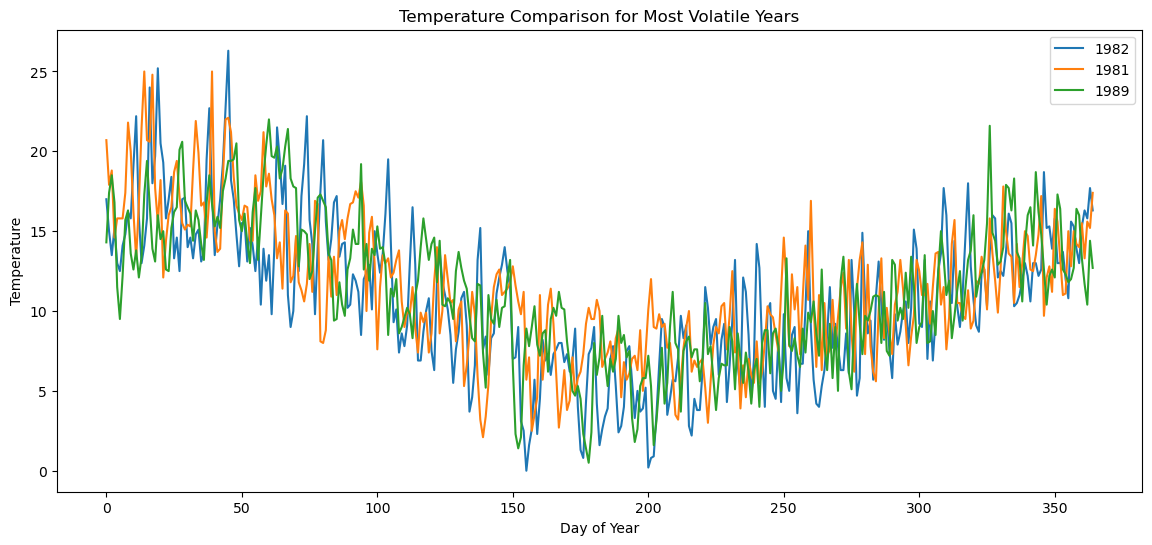

In [30]:
top_years = top_3_volatile.index.year

plt.figure(figsize=(14,6))

for year in top_years:
    
    yearly_data = df.loc[str(year), "Temp"].reset_index(drop=True)
    
    plt.plot(yearly_data, label=str(year))

plt.title("Temperature Comparison for Most Volatile Years")
plt.xlabel("Day of Year")
plt.ylabel("Temperature")
plt.legend()

plt.show()


### Why These Years Might Show Higher Volatility

- **Extreme seasonal cycles:** the main driver of a high standard deviation in a given year isn't necessarily irregular day-to-day behavior, but a large gap between winter and summer temperatures. If a winter was much colder than usual and the following summer much hotter than usual, observations end up far from the yearly mean, which pushes volatility sharply higher.
- **Large-scale climate phenomena (e.g. El Niño / La Niña):** sudden shifts in atmospheric systems — such as strong El Niño phases in the early 1980s — can shift air masses and produce months with extreme temperature anomalies.
- **Sudden regime shifts:** in some years the plot shows an abrupt jump or drop partway through, suggesting a markedly different air mass moved in mid-year.


## Exercise 2
 — Missing Data Imputation Challenge

1. Randomly delete **10% of the data**.  
2. Try three methods of filling the gaps:
   - linear interpolation  
   - rolling mean  
   - seasonal interpolation (use month group means)  
3. Compare the **RMSE** between the imputed series and the original series.  
4. Explain which method performs best and why.



---



In [31]:
import numpy as np


df_imp = df.copy()

np.random.seed(42)

missing_idx = np.random.choice(
    df_imp.index,
    size=int(len(df_imp) * 0.10),
    replace=False
)

original_values = df_imp.loc[missing_idx, "Temp"].copy()

df_imp.loc[missing_idx, "Temp"] = np.nan

print(df_imp["Temp"].isna().sum())


365


In [32]:
linear_fill = df_imp["Temp"].interpolate(method="linear")


In [33]:
rolling_mean = (
    df_imp["Temp"]
    .fillna(
        df_imp["Temp"]
        .rolling(30, min_periods=1)
        .mean()
    )
)


In [34]:
monthly_means = df.groupby(df.index.month)["Temp"].mean()

seasonal_fill = df_imp["Temp"].copy()

for idx in missing_idx:

    month = pd.to_datetime(idx).month
    
    seasonal_fill.loc[idx] = monthly_means[month]


In [35]:
from sklearn.metrics import mean_squared_error

# true values
y_true = original_values.sort_index()

# predictions
y_linear = linear_fill.loc[missing_idx].sort_index()
y_roll = rolling_mean.loc[missing_idx].sort_index()
y_seasonal = seasonal_fill.loc[missing_idx].sort_index()

# RMSE
rmse_linear = np.sqrt(mean_squared_error(y_true, y_linear))

rmse_roll = np.sqrt(mean_squared_error(y_true, y_roll))

rmse_seasonal = np.sqrt(mean_squared_error(y_true, y_seasonal))

print("Linear RMSE:", rmse_linear)
print("Rolling Mean RMSE:", rmse_roll)
print("Seasonal RMSE:", rmse_seasonal)


Linear RMSE: 2.2559544076051945
Rolling Mean RMSE: 2.8724674584954895
Seasonal RMSE: 2.7161039672780114


In [36]:
results = pd.DataFrame({
    "Method": [
        "Linear Interpolation",
        "Rolling Mean",
        "Seasonal Monthly Mean"
    ],
    "RMSE": [
        rmse_linear,
        rmse_roll,
        rmse_seasonal
    ]
})

results.sort_values("RMSE")


,Method,RMSE
0,Linear Interpolation,2.255954
2,Seasonal Monthly Mean,2.716104
1,Rolling Mean,2.872467


### Why Linear Interpolation Performed Best

- **Why linear wins outright:** temperature data has very strong local (short-range) dependency — today's temperature correlates strongly with yesterday's and tomorrow's. Linear interpolation exploits exactly this: it draws a line between the day before and after a gap and estimates the missing point from it, preserving the naturally smooth, locally continuous behavior of weather data.
- **Why the seasonal method came second:** the seasonal method captures the broad, repeating yearly pattern (e.g. it "knows" July is warm and January is cold), but ignores day-to-day, local variation entirely. If a specific January day was unusually cold due to a sudden cold snap, the seasonal method can't capture that — it only substitutes the month's overall average — so its error is larger than linear's.
- **Why the rolling mean was weakest:** a 30-day rolling mean strongly over-smooths the data. It suppresses sharp, short-term fluctuations and substitutes a very gentle value (roughly the last month's average), which ends up far from the true temperature on that specific day.


# Time-Series Decomposition  


--------------------------------------------


## 1. Additive vs. Multiplicative Models

A decomposition model tries to split a time series into 3 parts:

• **Trend:** long‑term increase/decrease  
• **Seasonality:** repeating patterns  
• **Residual:** everything unexplained (noise, anomalies, randomness)

Two common formulations:

### Additive Model
The components add together:

```
y(t) = Trend(t) + Seasonal(t) + Residual(t)
```

Use additive decomposition when:

• seasonal fluctuations are constant over time  
• amplitude does not increase with the level of the series  
• e.g., daily temperatures, stationary production cycles  

### Multiplicative Model
Components multiply:

```
y(t) = Trend(t) × Seasonal(t) × Residual(t)
```

Use multiplicative decomposition when:

• seasonal amplitude grows as the trend grows  
• variance increases with level  
• e.g., sales data with growth, energy demand with population growth  

If unsure, visually inspect the series.  
If the seasonality gets larger as the series grows → multiplicative is better.

--------------------------------------------
## 2. Decomposition Using statsmodels

We’ll use `seasonal_decompose` from `statsmodels`.



In [46]:
ts = df["Temp"]

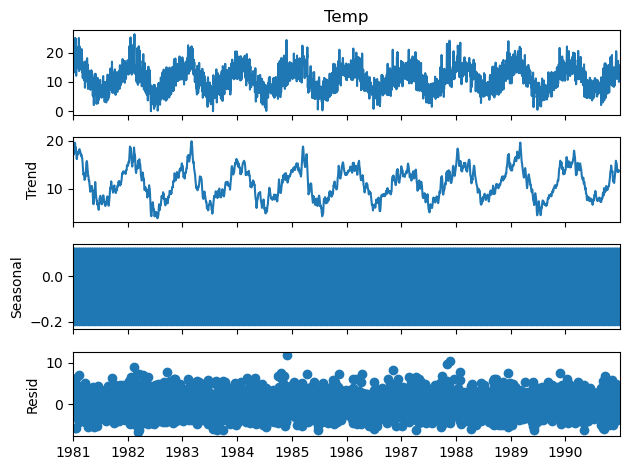

In [47]:

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


result = seasonal_decompose(
    ts,
    model='additive',   # or 'multiplicative'
    period=12           # monthly seasonality example
)

result.plot()
plt.show()



Key outputs:

• `result.trend`  
• `result.seasonal`  
• `result.resid`  

(These may contain NaNs at the edges due to windowing.)

--------------------------------------------
## 3. Plot Trend, Seasonal, and Residual Components

Example:


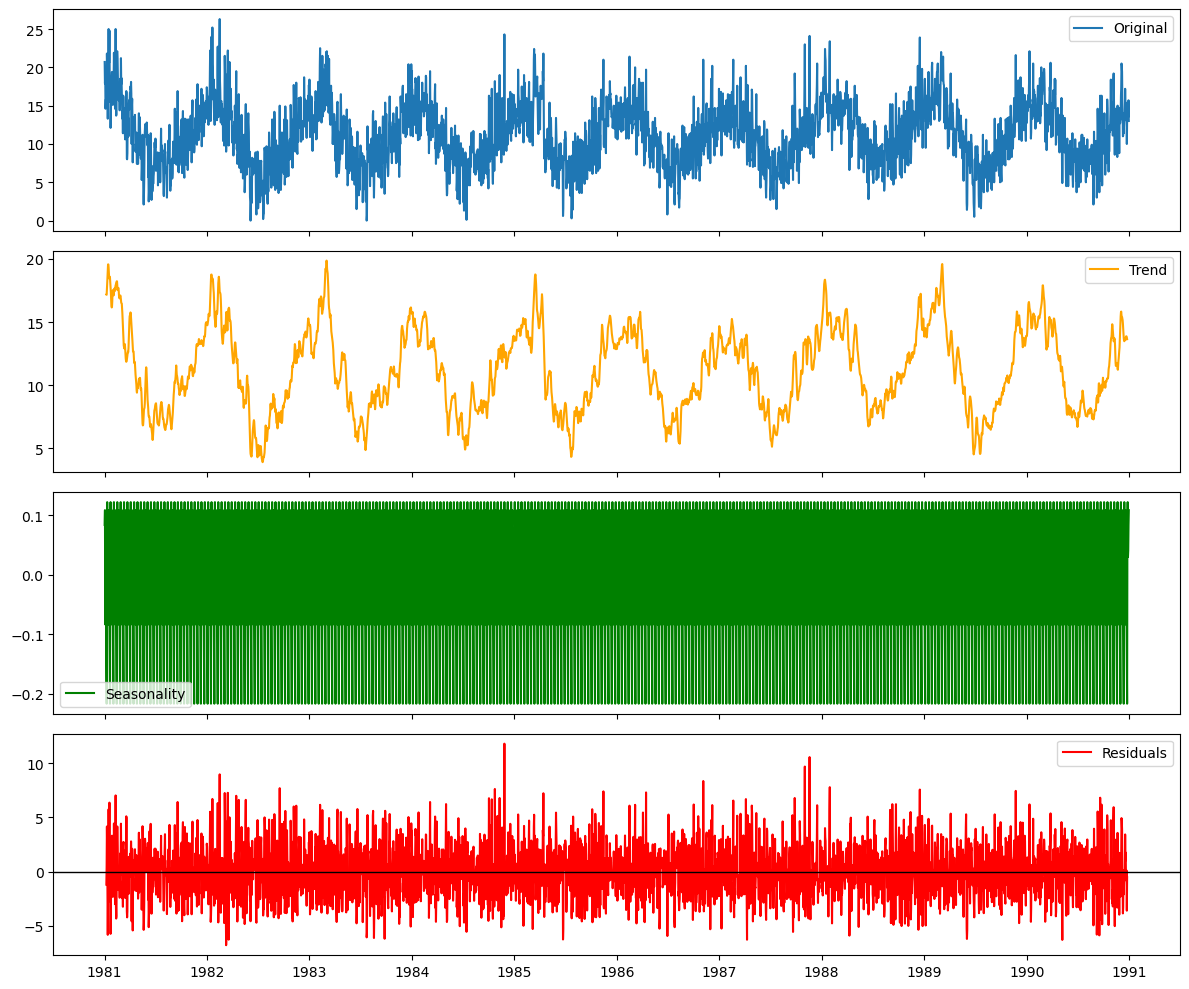

In [48]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(ts, label='Original')
ax[0].legend()

ax[1].plot(result.trend, label='Trend', color='orange')
ax[1].legend()

ax[2].plot(result.seasonal, label='Seasonality', color='green')
ax[2].legend()

ax[3].plot(result.resid, label='Residuals', color='red')
ax[3].axhline(0, color='black', linewidth=1)
ax[3].legend()

plt.tight_layout()
plt.show()



Students get a visual understanding of:

• slow-moving trend  
• repeating seasonal patterns  
• remaining unexplained variation  

--------------------------------------------
## 4. Interpretation and Use Cases

### How to interpret:

• **Trend**  
  Identifies long-term direction. Useful for forecasting or detecting structural change.

• **Seasonality**  
  Helps quantify repeating patterns (daily, weekly, monthly cycles).

• **Residuals**  
  Should ideally look like random noise.  
  Patterns in residuals indicate model misspecification.

### When decomposition is useful:

• anomaly detection (large residuals)  
• deseasonalizing before modeling  
• exploratory data analysis  
• preparing inputs for regression or machine learning models  
• understanding the underlying structure before forecasting  

--------------------------------------------



## Exercise 1 — Compare Additive vs. Multiplicative Decompositions

### Tasks:

1. Run both additive and multiplicative decompositions on the same series.  
2. Plot each component side by side.  
3. Compare:
   • seasonal amplitude behavior  
   • residual variance  
   • stability of trend  
4. Conclude which model is more appropriate and why.

### Expected output:

• 6 plots (original + components for both models)  
• A written justification grounded in the visual behavior of components




In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts_pos = ts - ts.min() + 1

additive = seasonal_decompose(
    df["Temp"],
    model="additive",
    period=365
)

multiplicative = seasonal_decompose(
    ts_pos,
    model="multiplicative",
    period=365
)


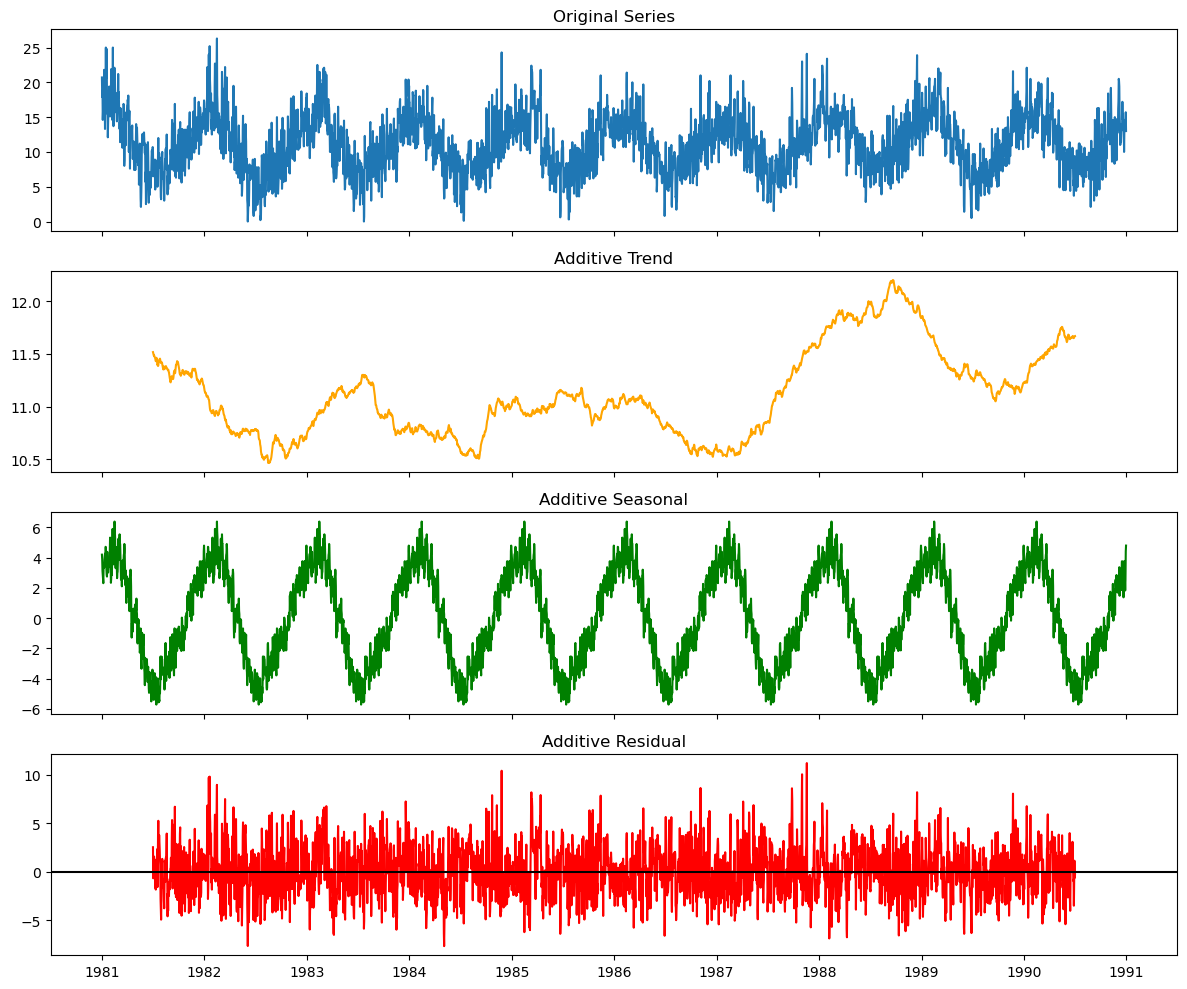

In [50]:
fig, ax = plt.subplots(4,1, figsize=(12,10), sharex=True)

ax[0].plot(ts)
ax[0].set_title("Original Series")

ax[1].plot(additive.trend, color="orange")
ax[1].set_title("Additive Trend")

ax[2].plot(additive.seasonal, color="green")
ax[2].set_title("Additive Seasonal")

ax[3].plot(additive.resid, color="red")
ax[3].axhline(0, color="black")
ax[3].set_title("Additive Residual")

plt.tight_layout()
plt.show()



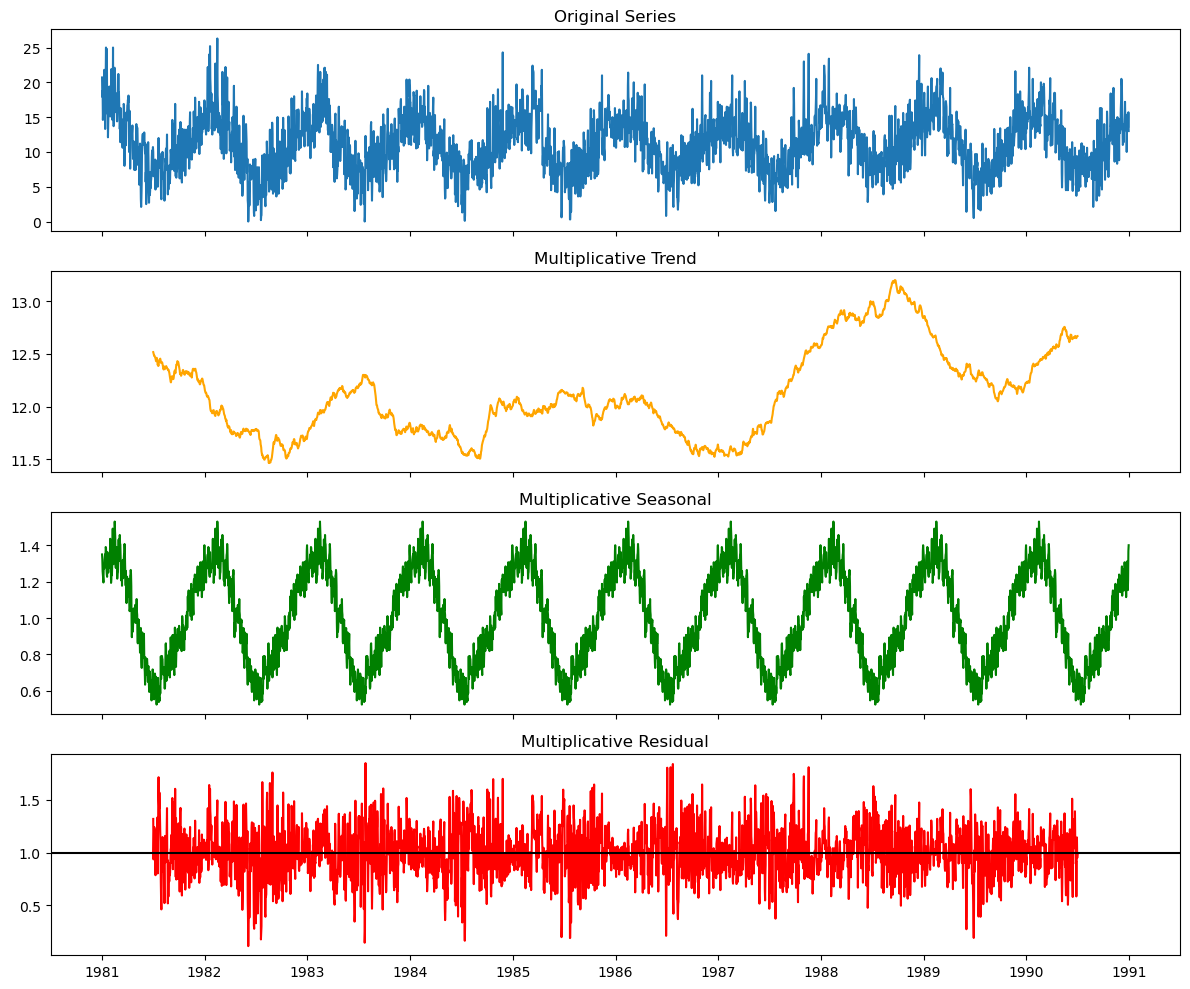

In [51]:
fig, ax = plt.subplots(4,1, figsize=(12,10), sharex=True)

ax[0].plot(ts)
ax[0].set_title("Original Series")

ax[1].plot(multiplicative.trend, color="orange")
ax[1].set_title("Multiplicative Trend")

ax[2].plot(multiplicative.seasonal, color="green")
ax[2].set_title("Multiplicative Seasonal")

ax[3].plot(multiplicative.resid, color="red")
ax[3].axhline(1, color="black")
ax[3].set_title("Multiplicative Residual")

plt.tight_layout()
plt.show()


### Residuals

- **Additive model:** residuals are on the original scale (°C) and range roughly between −5 and +10 — i.e., in the worst case the model's estimate is off by ~10°C too high or ~5°C too low. The residuals oscillate around zero symmetrically with no obvious trend, indicating the model has filtered out the systematic structure well.
- **Multiplicative model:** residuals are ratios, roughly between 0.5 and 1.5. A value of 1 means a perfect prediction; 1.5 means the actual temperature was 1.5× the trend×seasonal estimate, and 0.5 means it was half of it.
- **Homoscedasticity:** for this station's data, the spread of the noise stays roughly constant over the full ten years — the residual variance is homoscedastic, which is the assumption the additive model relies on.
- **Unstable scaling in the multiplicative model:** because the multiplicative residual is $Resid = \frac{Y}{T \times S}$, on very cold days when temperature approaches zero, the denominator shrinks and the residual ratio can spike artificially (e.g. toward 1.5–2). This makes the multiplicative model's noise unstable, whereas the additive model's residuals behave consistently regardless of whether the day is hot or cold.
- The difference in fit quality between the two models is on the order of a few billionths — effectively negligible; both reach essentially the same optimum.
- Given that the additive model's residuals oscillate more evenly and stably around zero without the distortions the multiplicative model shows on extreme-temperature days, the **additive model** is selected as the better fit for this series.


# Stationarity & the ADF Test



## 1. What Is Stationarity?

A time series is **stationary** if its statistical properties do **not change over time**.

This means:

• constant mean  
• constant variance  
• constant distribution  
• no long‑term trend  
• no evolving seasonality  

In practice, real-world time series are often **non‑stationary**, especially those with:

• upward/downward trends  
• seasonal cycles  
• fluctuating variance (heteroscedasticity)  

Many forecasting models (ARIMA, SARIMA, etc.) assume **stationarity**, so understanding and testing for it is essential.

---

### 1.1 Visual Example: Non‑Stationary Series

Typical characteristics:

• upward trend  
• rolling mean increases  
• rolling variance increases


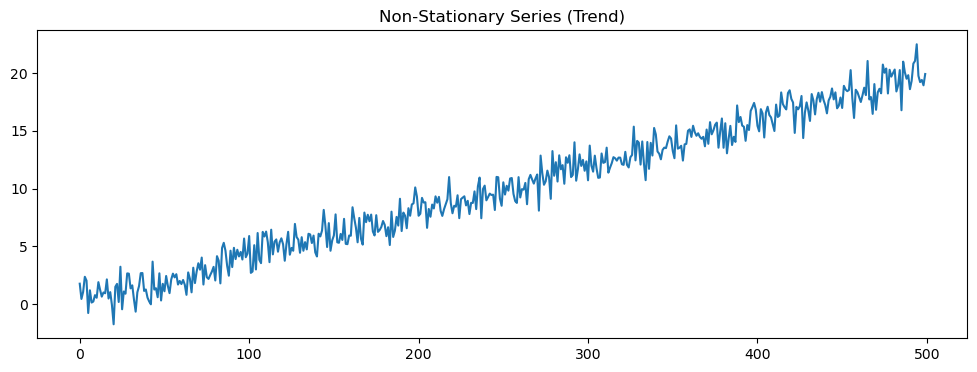

In [52]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 500

trend = np.linspace(0, 20, n)
noise = np.random.normal(0, 1, n)
series_nonstationary = trend + noise

plt.figure(figsize=(12,4))
plt.plot(series_nonstationary)
plt.title("Non‑Stationary Series (Trend)")
plt.show()



### 1.2 Visual Example: Stationary Series

Characteristics:

• mean and variance are stable  
• no visible long‑term drift


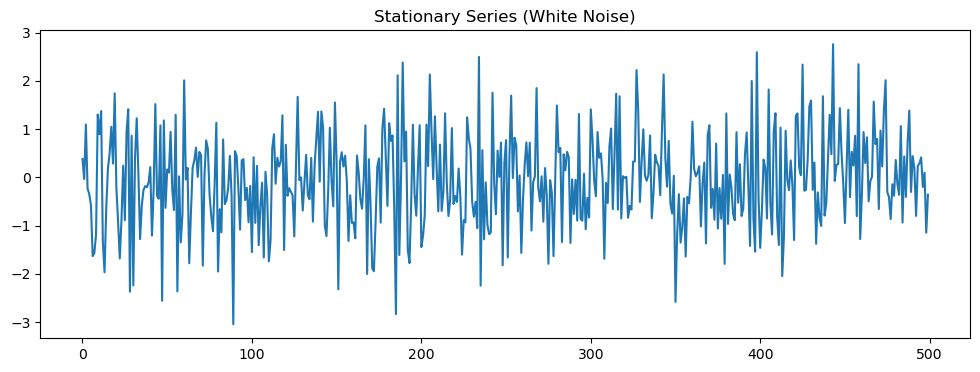

In [53]:

noise_stationary = np.random.normal(0, 1, n)

plt.figure(figsize=(12,4))
plt.plot(noise_stationary)
plt.title("Stationary Series (White Noise)")
plt.show()


## 2. Statistical Tests for Stationarity

Visual inspection helps, but formal tests give stronger evidence.

Common tests:

• **ADF (Augmented Dickey–Fuller)**  
• KPSS  
• PP (Phillips–Perron)

In this notebook we focus on **ADF**, the most widely used test when preparing data for ARIMA/SARIMA.

---

## 3. The ADF Test

The Augmented Dickey–Fuller test evaluates the presence of a **unit root**.

Interpretation:

• **Null hypothesis (H0):** The series is non‑stationary  
• **Alternative (H1):** The series is stationary  

Key outputs:

• ADF statistic  
• p‑value  
• Critical values at common significance levels (1%, 5%, 10%)

#### Decision rule:

If `p-value < 0.05`, we reject H0 → **series is stationary**.  
If `p-value ≥ 0.05`, we fail to reject H0 → **series is non‑stationary**.

---

### 3.1 ADF Test Implementation


In [54]:

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    result = adfuller(series)
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for k, v in result[4].items():
        print(f"  {k}: {v}")

adf_report(series_nonstationary, "Non‑Stationary Example")


--- ADF Test: Non‑Stationary Example ---
ADF Statistic: 0.4170556669343463
p-value: 0.9821216781943712
Critical Values:
  1%: -3.4440184853599876
  5%: -2.867567599912013
  10%: -2.5699804779975883


## 4. Transformations to Achieve Stationarity

Common transformations:

• log transform (stabilizes multiplicative variance)  
• square root/power transforms  
• differencing (removes trend and seasonality)  



### 4.1 Log Transform



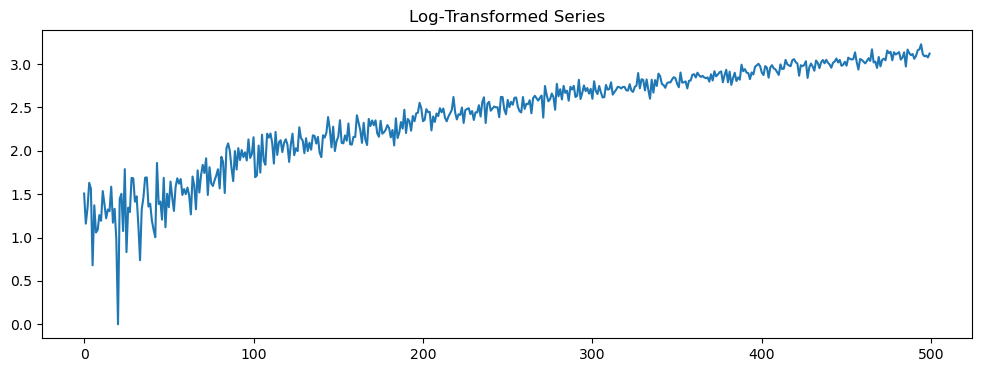

--- ADF Test: Log Transform ---
ADF Statistic: -3.070250144526944
p-value: 0.02883459184961457
Critical Values:
  1%: -3.4440184853599876
  5%: -2.867567599912013
  10%: -2.5699804779975883


In [55]:

series_log = np.log(series_nonstationary - series_nonstationary.min() + 1)

plt.figure(figsize=(12,4))
plt.plot(series_log)
plt.title("Log‑Transformed Series")
plt.show()

adf_report(series_log, "Log Transform")




### 4.2 First Differencing

Differencing removes the trend:


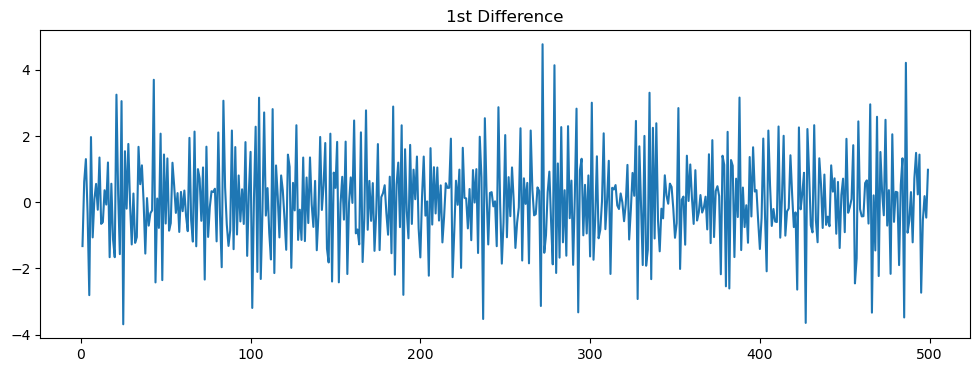

--- ADF Test: 1st Difference ---
ADF Statistic: -9.128505224763826
p-value: 3.0670102866193118e-15
Critical Values:
  1%: -3.4440184853599876
  5%: -2.867567599912013
  10%: -2.5699804779975883


In [56]:


series_diff = pd.Series(series_nonstationary).diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(series_diff)
plt.title("1st Difference")
plt.show()

adf_report(series_diff, "1st Difference")




### 4.3 Combination: Log + Difference


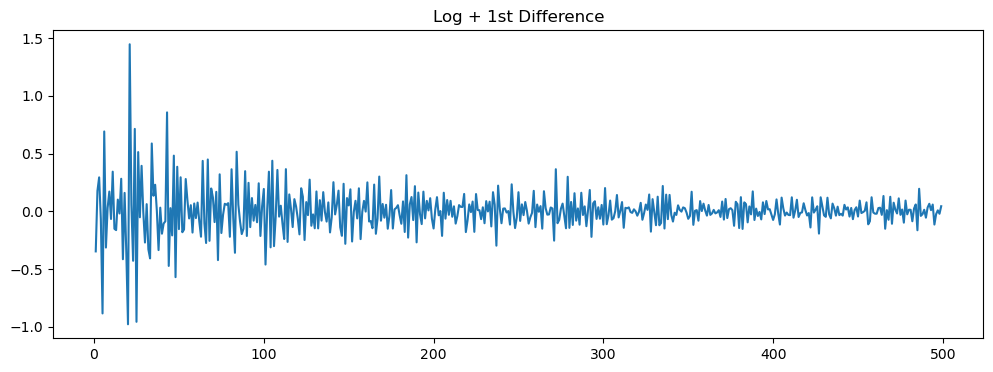

--- ADF Test: Log + Difference ---
ADF Statistic: -8.179561817076985
p-value: 8.200941741392926e-13
Critical Values:
  1%: -3.4440184853599876
  5%: -2.867567599912013
  10%: -2.5699804779975883


In [57]:

series_log_diff = pd.Series(series_log).diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(series_log_diff)
plt.title("Log + 1st Difference")
plt.show()

adf_report(series_log_diff, "Log + Difference")






## 5. Before/After Comparison



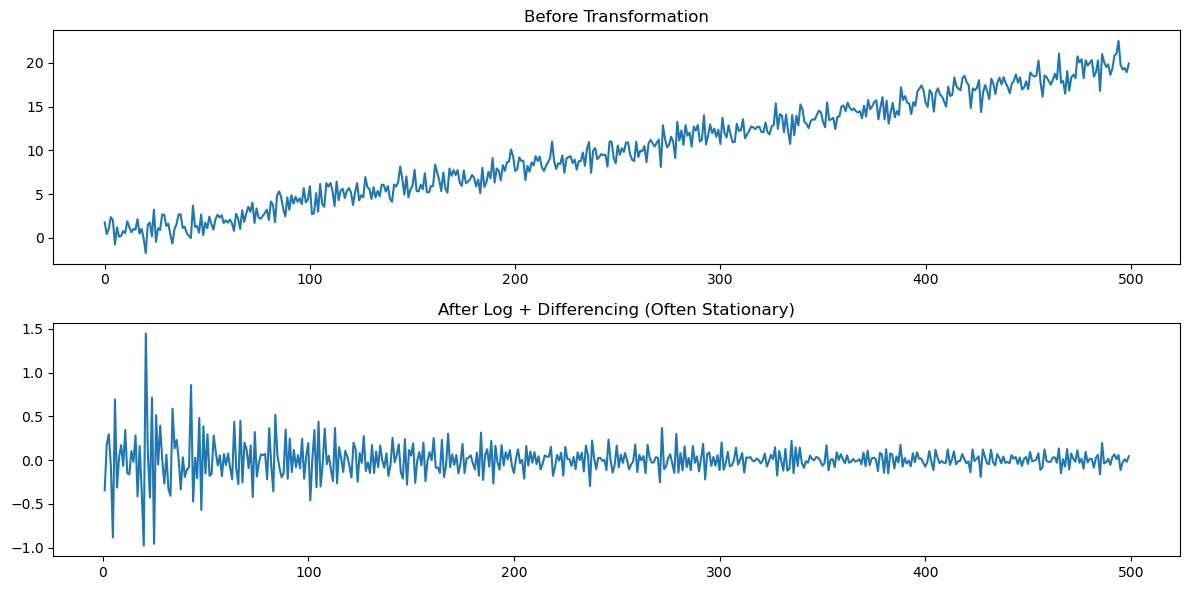

In [58]:


plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(series_nonstationary)
plt.title("Before Transformation")

plt.subplot(2,1,2)
plt.plot(series_log_diff)
plt.title("After Log + Differencing (Often Stationary)")
plt.tight_layout()
plt.show()



##EXERCISE 1

**Goal:** Understand the structural causes of non‑stationarity.

#### Instructions:

1. Generate **three** synthetic time series:
   - Series A: strong linear trend  
   - Series B: pure seasonal sinusoid  
   - Series C: random walk  

2. For each series:
   - plot it  
   - run an ADF test  
   - apply *minimal* transformation(s) to make it stationary  
   - explain **why** that transformation works  

3. For each final stationary version:
   - compute and plot the autocorrelation (ACF)  
   - explain differences among the three  





1.Generate the Three Series

In [59]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 400

# Series A — Linear Trend
trend = np.linspace(0, 20, n)
noise = np.random.normal(0, 1, n)
series_A = trend + noise

# Series B — Pure Seasonal Sinusoid
t = np.arange(n)
series_B = 10 * np.sin(2*np.pi*t/50) + np.random.normal(0,0.5,n)

# Series C — Random Walk
steps = np.random.normal(0,1,n)
series_C = np.cumsum(steps)


2.for each
 plot:

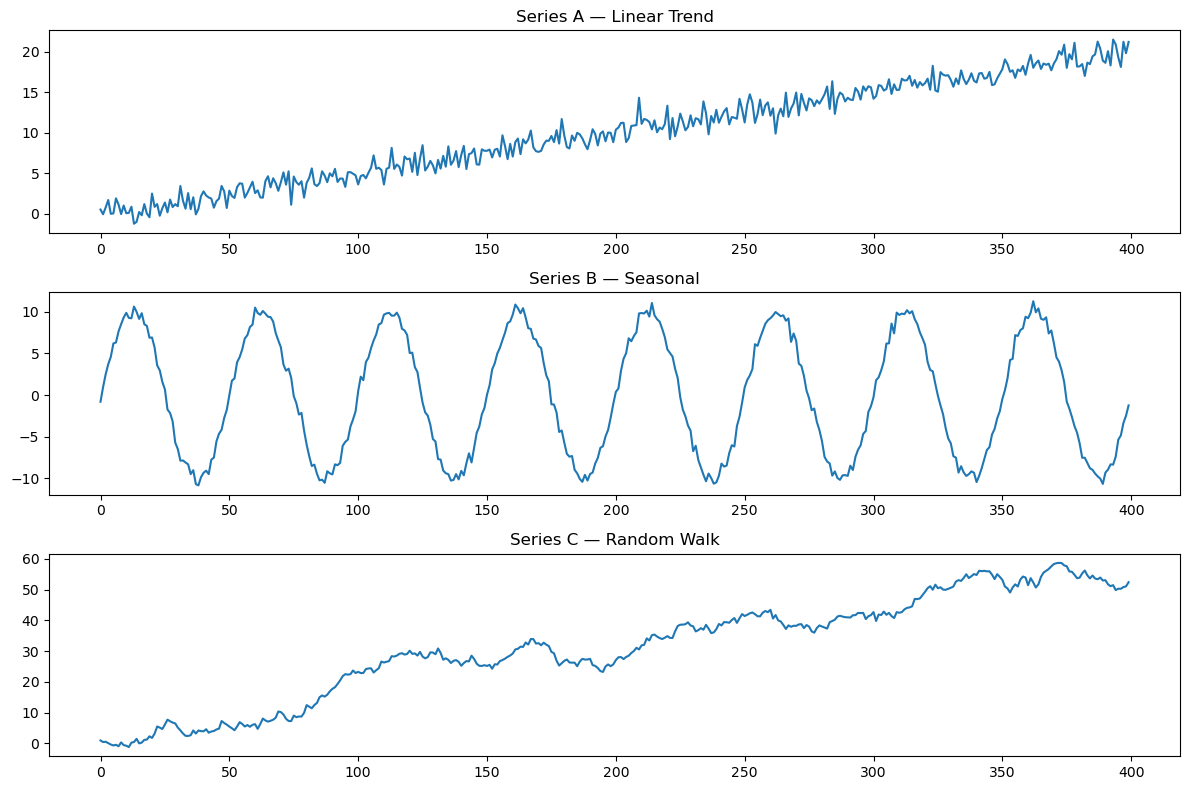

In [60]:
fig, ax = plt.subplots(3,1, figsize=(12,8))

ax[0].plot(series_A)
ax[0].set_title("Series A — Linear Trend")

ax[1].plot(series_B)
ax[1].set_title("Series B — Seasonal")

ax[2].plot(series_C)
ax[2].set_title("Series C — Random Walk")

plt.tight_layout()
plt.show()


-Run ADF Tests

In [61]:
def adf_report(series, name):
    result = adfuller(series)
    print(f"\n{name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_report(series_A, "Series A")
adf_report(series_B, "Series B")
adf_report(series_C, "Series C")



Series A
ADF Statistic: -0.11006696731070581
p-value: 0.948426547195941

Series B
ADF Statistic: -12.76883465922775
p-value: 7.850490787743694e-24

Series C
ADF Statistic: -1.252122834142258
p-value: 0.6507818778049681


-Apply Minimal Transformations

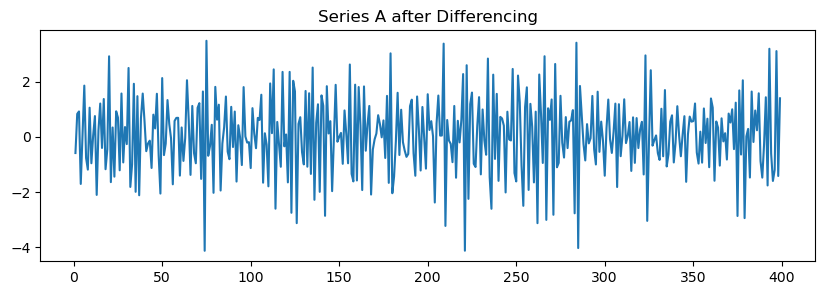


Series A Stationary
ADF Statistic: -9.45374781385479
p-value: 4.543063265673652e-16


In [63]:
#Series A — Remove Trend with Differencin
A_diff = pd.Series(series_A).diff().dropna()

plt.figure(figsize=(10,3))
plt.plot(A_diff)
plt.title("Series A after Differencing")
plt.show()

adf_report(A_diff, "Series A Stationary")


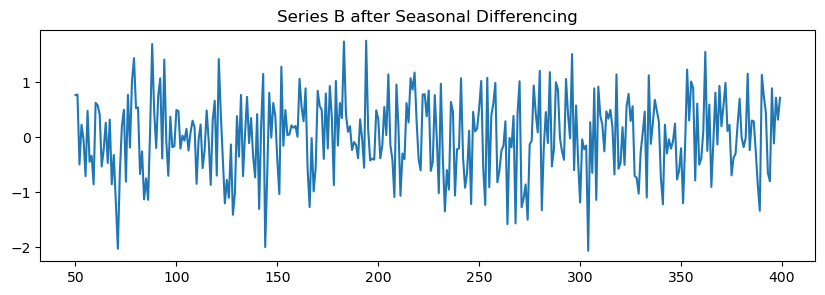


Series B Stationary
ADF Statistic: -18.147162894251966
p-value: 2.4816349202005592e-30


In [64]:
#Series B — Remove Seasonality with Seasonal Differencing
B_diff = pd.Series(series_B).diff(50).dropna()

plt.figure(figsize=(10,3))
plt.plot(B_diff)
plt.title("Series B after Seasonal Differencing")
plt.show()

adf_report(B_diff, "Series B Stationary")


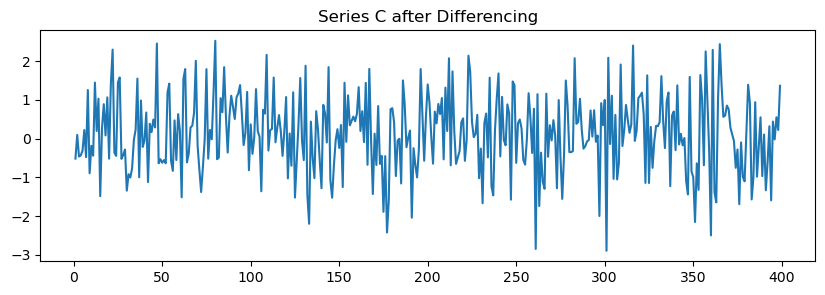


Series C Stationary
ADF Statistic: -20.401035239816085
p-value: 0.0


In [65]:
#Series C — Random Walk → First Difference
C_diff = pd.Series(series_C).diff().dropna()

plt.figure(figsize=(10,3))
plt.plot(C_diff)
plt.title("Series C after Differencing")
plt.show()

adf_report(C_diff, "Series C Stationary")


-explain why this works:
A:
Differencing removes the linear trend by subtracting consecutive values, stabilizing the mean.
B:
Seasonal differencing subtracts values from the previous cycle, removing the repeating seasonal structure.
C:
A random walk is the cumulative sum of white noise.
Differencing reverses the accumulation and recovers the underlying noise process.

3.ACF of Final Stationary Series

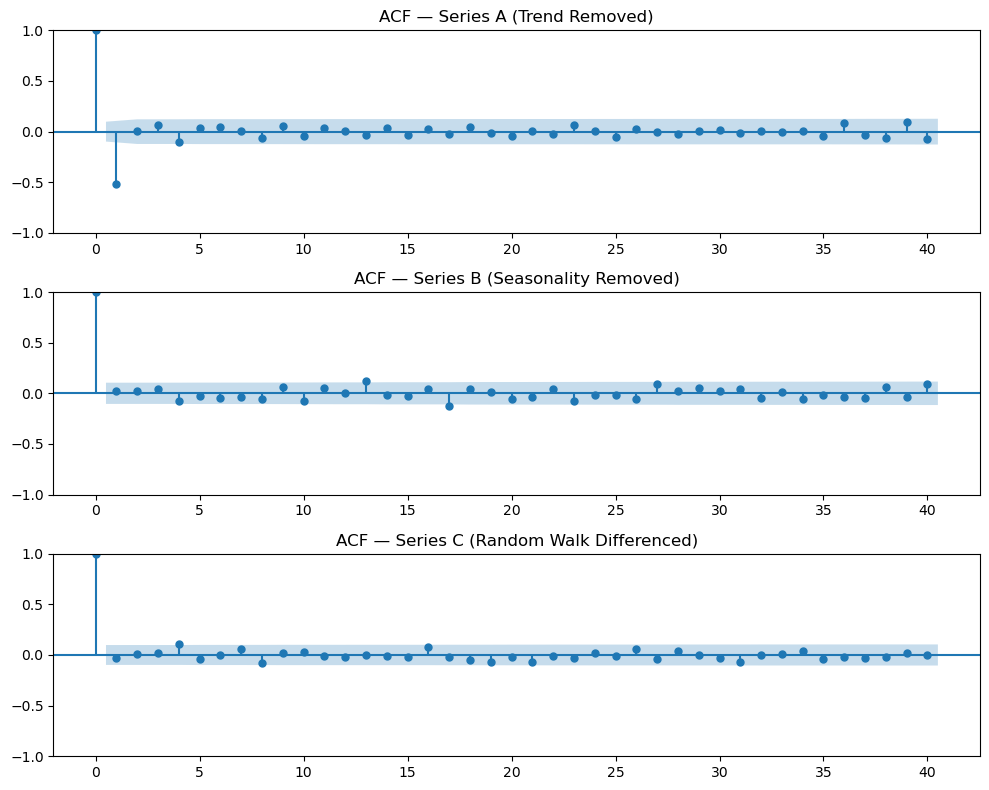

In [66]:
fig, ax = plt.subplots(3,1, figsize=(10,8))

plot_acf(A_diff, ax=ax[0], lags=40)
ax[0].set_title("ACF — Series A (Trend Removed)")

plot_acf(B_diff, ax=ax[1], lags=40)
ax[1].set_title("ACF — Series B (Seasonality Removed)")

plot_acf(C_diff, ax=ax[2], lags=40)
ax[2].set_title("ACF — Series C (Random Walk Differenced)")

plt.tight_layout()
plt.show()


Explain:

Series A — Trend
The original series is non‑stationary due to a deterministic linear trend.
First differencing removes this trend, stabilizing the mean.
The ACF of the stationary version decays quickly, indicating short‑range dependence.

Series B — Seasonality
The sinusoidal structure introduces strong periodic autocorrelation.
Seasonal differencing removes the repeating cycle by subtracting values one full period apart.
The ACF of the stationary series shows much weaker periodic spikes.

Series C — Random Walk
Random walks contain a unit root, making them inherently non‑stationary.
Differencing transforms the process into white noise.
The ACF of the differenced series shows almost no significant autocorrelation.

Different sources of non‑stationarity require different transformations:

Trend → First Differencing
Seasonality → Seasonal Differencing
Random Walk → First Differencing (removes unit root)

### Structural Causes of Non-Stationarity

**Goal**

The goal of this exercise is to understand the different structural sources of non-stationarity in time-series data, and how to restore stationarity using appropriate transformations. Three synthetic series were generated to illustrate three common causes of non-stationarity: a deterministic trend, seasonality, and a stochastic trend (random walk). Each series was inspected visually, tested with the Augmented Dickey-Fuller (ADF) test, transformed to achieve stationarity, and then analyzed with the autocorrelation function (ACF).

**1. Series A — Linear Trend**

*Visual behavior:* a strong upward linear trend plus random noise; the plot clearly shows the series' level increasing steadily over time.

*ADF test:* statistic −0.11, p-value 0.948. Since p ≫ 0.05, the null hypothesis is not rejected — the series is non-stationary. The root cause is the deterministic upward trend, which makes the mean change over time.

*Transformation applied:* first-order differencing, $y'_t = y_t - y_{t-1}$, which removes the trend by measuring the change between consecutive observations.

*Result after transformation:* statistic −9.45, p-value 4.54 × 10⁻¹⁶ — strong evidence the differenced series is stationary.

*Why it works:* differencing removes the trend component because the (roughly constant) increase between observations is cancelled out; the remaining series oscillates around a stable mean with roughly constant variance.

*ACF behavior:* the stationary version shows autocorrelation decaying quickly after the first few lags — only short-range correlation remains, typical of a stationary process plus noise.

**2. Series B — Seasonal Sine Pattern**

*Visual behavior:* a clear sinusoidal pattern with a repeating 50-observation cycle — strong evidence of seasonality.

*ADF test:* statistic −12.77, p-value 7.85 × 10⁻²⁴. Although the p-value alone suggests stationarity in the statistical sense, the visual pattern reveals a strong periodic structure — the series has no stable local mean since values rise and fall regularly within each cycle. In practice this kind of repeating dependency is usually treated as systematic structure that should be removed for most forecasting models.

*Transformation applied:* seasonal differencing with period s = 50: $y'_t = y_t - y_{t-50}$.

*Result after transformation:* statistic −18.15, p-value 2.48 × 10⁻³⁰ — a fully stationary series.

*Why it works:* seasonal differencing removes the repeating pattern by subtracting the value from the previous cycle. Since the sinusoidal structure repeats every 50 steps, subtracting the value 50 steps back cancels out most of the periodic component, leaving mostly random fluctuation.

*ACF behavior:* the original series has strong periodic peaks at multiples of lag 50. After seasonal differencing these largely disappear; the ACF decays faster and autocorrelation becomes much weaker, indicating the seasonal structure has been removed.

**3. Series C — Random Walk**

*Visual behavior:* the cumulative sum of random noise. The plot shows wandering, irregular behavior with no clear mean, and the variance appears to grow over time.

*ADF test:* statistic −1.25, p-value 0.651. The large p-value means the series is non-stationary. Random walks have a unit root — shocks accumulate over time and permanently shift the series' level.

*Transformation applied:* first-order differencing, $y'_t = y_t - y_{t-1}$.

*Result after transformation:* statistic −20.40, p-value ≈ 0.0 — very strong evidence of stationarity.

*Why it works:* a random walk is, by definition, the cumulative sum of random noise. Differencing reverses that accumulation and essentially recovers the original white noise.

*ACF behavior:* the differenced series shows almost no significant autocorrelation — most lags fall within the confidence band, characteristic of white noise.


### Conclusion

**Comparing the three stationary series**

After applying the minimal necessary transformation, all three series become stationary, but their autocorrelation structures differ:
- **Series A** (trend removed) still shows some short-range autocorrelation because the remaining noise has local dependency; its ACF decays gradually.
- **Series B** (seasonality removed) originally had strong periodic correlations; after seasonal differencing those peaks disappear and the structure becomes much weaker.
- **Series C** (random-walk differenced) behaves almost like pure white noise, since the differenced process is essentially the original random noise.

**Takeaway**

This exercise shows that non-stationarity can arise from different structural sources:
- Deterministic trends
- Seasonal cycles
- Stochastic trends (unit roots)

Each requires a specific transformation to achieve stationarity:
- First-order differencing effectively removes deterministic trends and random-walk behavior.
- Seasonal differencing removes repeating periodic patterns.

Once the appropriate transformation is applied, the resulting series have stable statistical properties and weaker autocorrelation structure — suitable for many forecasting models such as ARIMA or SARIMA.


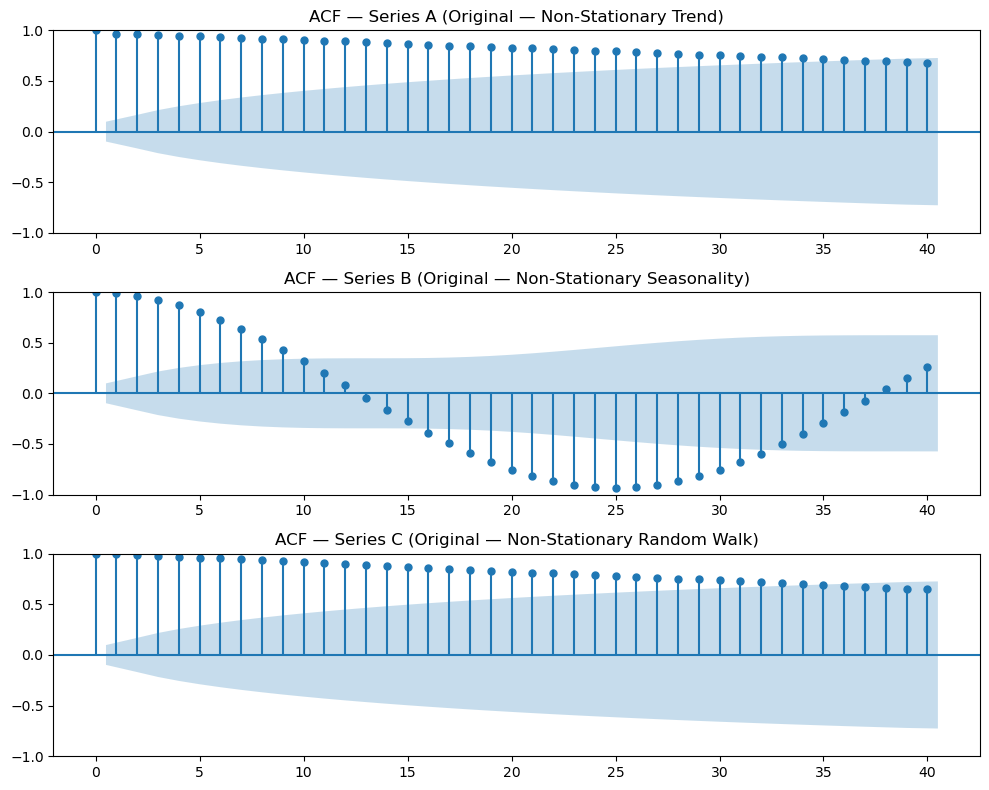

In [68]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(3, 1, figsize=(10, 8))

plot_acf(series_A, ax=ax[0], lags=40)
ax[0].set_title("ACF — Series A (Original — Non-Stationary Trend)")

plot_acf(series_B, ax=ax[1], lags=40)
ax[1].set_title("ACF — Series B (Original — Non-Stationary Seasonality)")

plot_acf(series_C, ax=ax[2], lags=40)
ax[2].set_title("ACF — Series C (Original — Non-Stationary Random Walk)")

plt.tight_layout()
plt.show()

# Lag Feature Engineering



## 1. What Are Lags and Why Use Them?

**Definition:**  
A *lag feature* is simply a past value of the time series that you use as an input to predict a future value.

Examples:

• lag_1 = yesterday's value  
• lag_7 = last week's value  
• lag_30 = last month's approximate value  

Lags are powerful because many real‑world systems depend on their past:

• temperature today is similar to yesterday  
• electricity demand depends on previous hours  
• stock volatility relates to recent values  
• sales follow weekly and monthly cycles  


Think of a time series as a sequence:

x₁, x₂, x₃, …, xₜ

A lag feature copies earlier values and uses them as predictors.

Example:
- Lag 1 (xₜ₋₁): the value one step before  
- Lag 2 (xₜ₋₂): two steps before  
- Lag 7 (xₜ₋₇): seven steps before  

So your dataset might look like this:

time | value | lag_1 | lag_2  
-----|--------|--------|-------  
t=3  | 10     | 7      | 5     

Here, 10 is predicted using value 7 and 5 from previous steps.

Why lag features are useful:
- Time series often show **autocorrelation**: the past influences the future.
- Models like linear regression, XGBoost, Random Forests, and neural networks can't automatically “remember” previous values. Lag features give them that memory.

Common lags used:
- Short-term: 1, 2, 3, …  
- Seasonal: 24 (hour), 7 (daily weekly seasonality), 12 (monthly yearly seasonality)  
- Domain-specific: depends on your data behavior

Lag features vs. rolling features:
- Lag = single past value  
- Rolling = summary of multiple past values (mean, sum, std, etc.)




--------------------------------------------

## 2. Implementing Basic Lag Features

Assume you have a pandas Series or DataFrame called `df` with a column `"value"`.


In [71]:

import pandas as pd

# example lags
#df['lag_1'] = df['value'].shift(1)
#df['lag_2'] = df['value'].shift(2)
#df['lag_7'] = df['value'].shift(7)
#df['lag_30'] = df['value'].shift(30)

#df.head(10)

df["lag_1"] = df["Temp"].shift(1)
df["lag_2"] = df["Temp"].shift(2)
df["lag_7"] = df["Temp"].shift(7)
df["lag_30"] = df["Temp"].shift(30)

df.head(10)


,Temp,Month,z,lag_1,lag_2,lag_7,lag_30
Date,,,,,,,
1981-01-01,20.7,1,2.338563,NaN,NaN,NaN,NaN
1981-01-02,17.9,1,1.650913,20.7,NaN,NaN,NaN
1981-01-03,18.8,1,1.871943,17.9,20.7,NaN,NaN
1981-01-04,14.6,1,0.840467,18.8,17.9,NaN,NaN
1981-01-05,15.8,1,1.135175,14.6,18.8,NaN,NaN
1981-01-06,15.8,1,1.135175,15.8,14.6,NaN,NaN
1981-01-07,15.8,1,1.135175,15.8,15.8,NaN,NaN
1981-01-08,17.4,1,1.528118,15.8,15.8,20.7,NaN
1981-01-09,21.8,1,2.608711,17.4,15.8,17.9,NaN




Interpretation:

• `lag_1` is the most common predictive feature  
• `lag_7` captures weekly structure  
• `lag_30` captures monthly structure  

Important:  
`.shift()` introduces **missing values** at the start. You must handle them later (drop or fill).

--------------------------------------------

## 3. Autocorrelation and the ACF Plot

Autocorrelation = how much the series correlates with itself at different lags.

High autocorrelation at lag k implies:

> The value k steps in the past contains predictive information.

### ACF Plot


<Figure size 1000x400 with 0 Axes>

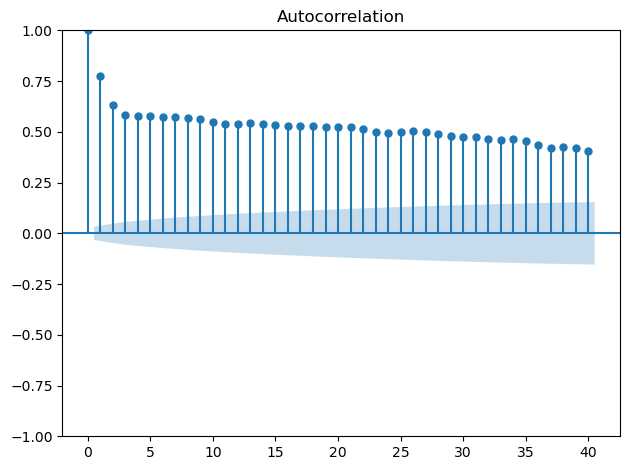

In [72]:

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(df["Temp"].dropna(), lags=40)
plt.tight_layout()
plt.show()


<Figure size 1000x400 with 0 Axes>

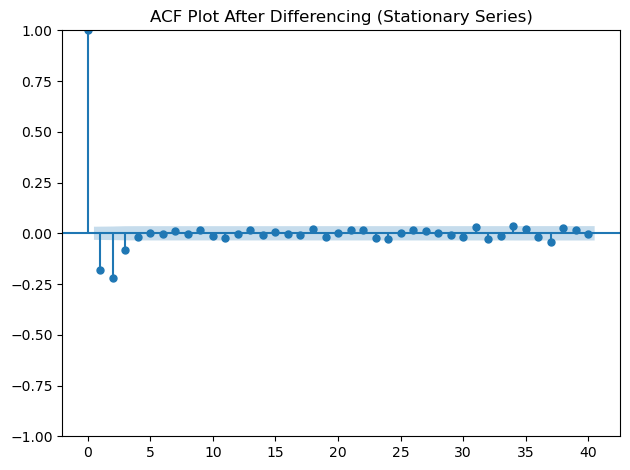

In [73]:
plt.figure(figsize=(10, 4))
plot_acf(df["Temp"].diff().dropna(), lags=40)
plt.title("ACF Plot After Differencing (Stationary Series)")
plt.tight_layout()
plt.show()


## 4. When To Use Different Lag Horizons

Different lags encode different types of behavior.

#### Short Lags (1–5)
Capture immediate dependencies. Useful for:
• temperature  
• stock returns  
• sensor readings  

#### Medium Lags (6–30)
Capture weekly/monthly cycles. Useful for:
• sales  
• electricity load  
• website traffic  

#### Long Lags (30–365)
Capture seasonal patterns and slow dynamics. Useful for:
• climate series  
• agriculture  
• energy  

Guideline:  
Always let the **ACF plot guide you** on which lags contain real predictive power.



--------------------------------------------
## Exercise 1 — Optimal Lag Selection via ACF Peaks


Identify the automatically “best” lag features using ACF structure.

#### Instructions

1. Compute the ACF of daily-min-temperature series for up to 60 lags.  
2. Create a function that:  
   • finds all local maxima in the ACF  
   • selects only peaks above a certain threshold (e.g., 0.2)  
3. Return a list of “recommended lags.”  
4. Build a DataFrame with only these lag columns.  
5. Plot all recommended lag features along with the target to visually inspect patterns.

#### Deliverables
• A function `select_lags_from_acf(series, max_lag)`  
• A list of peak lags  
• A cleaned feature matrix with only those lags  
• A short analysis explaining whether the ACF‑selected lags make intuitive sense




1 & 2.Compute ACF and Detect Peaks

In [80]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

def select_lags_from_acf(series, max_lag=60, threshold=0.2):

    acf_values = acf(series.dropna(), nlags=max_lag)

    recommended_lags = []

    for i in range(1, len(acf_values)-1):
        if (
            acf_values[i] > acf_values[i-1] and
            acf_values[i] > acf_values[i+1] and
            acf_values[i] > threshold
        ):
            recommended_lags.append(i)

    return recommended_lags, acf_values


In [ ]:
3.list of “recommended lags”

In [81]:
lags, acf_vals = select_lags_from_acf(df["Temp"], max_lag=60)

print("Recommended lags:", lags)


Recommended lags: [13, 18, 20, 26, 31, 34, 38, 52, 59]


4.Create Feature Matrix with Selected Lags

In [82]:
lagged_df = pd.DataFrame(index=df.index)

lagged_df["Temp"] = df["Temp"]

for lag in lags:
    lagged_df[f"lag_{lag}"] = df["Temp"].shift(lag)

lagged_df = lagged_df.dropna()

lagged_df.head()


,Temp,lag_13,lag_18,lag_20,lag_26,lag_31,lag_34,lag_38,lag_52,lag_59
Date,,,,,,,,,,
1981-03-01,17.8,21.2,13.7,25.0,21.9,15.5,18.7,12.1,17.4,20.7
1981-03-02,18.6,18.4,13.9,15.0,19.9,15.1,19.4,14.4,21.8,17.9
1981-03-03,17.0,16.6,18.3,13.7,16.6,15.4,17.2,16.0,20.0,18.8
1981-03-04,16.0,16.1,22.0,13.9,16.8,15.3,15.5,16.5,16.2,14.6
1981-03-05,13.3,15.7,22.1,18.3,14.6,18.8,15.1,18.7,13.3,15.8


5.Plot Target with Recommended Lag Features

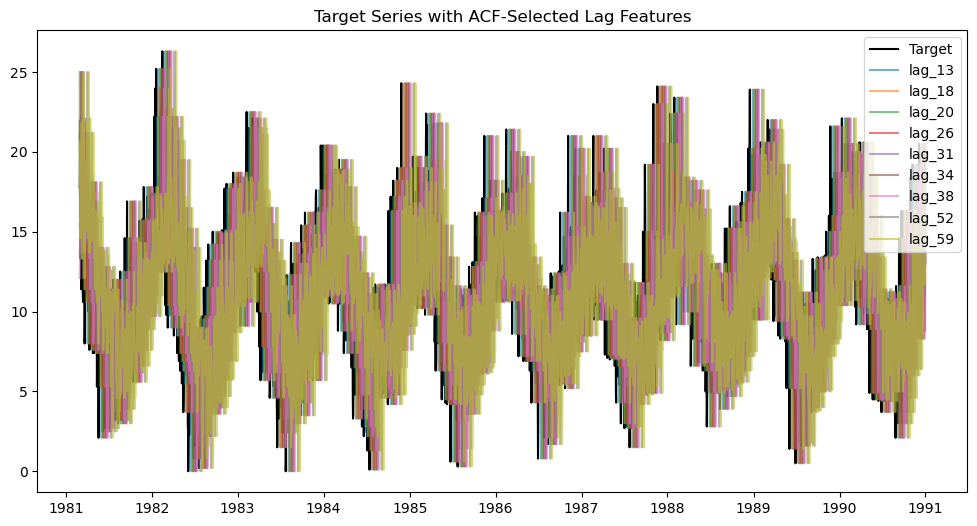

In [83]:
plt.figure(figsize=(12,6))

plt.plot(lagged_df["Temp"], label="Target", color="black")

for lag in lags:
    plt.plot(lagged_df[f"lag_{lag}"], alpha=0.6, label=f"lag_{lag}")

plt.legend()
plt.title("Target Series with ACF-Selected Lag Features")
plt.show()


### General Notes

**Interpreting lags selected via ACF**

The ACF plot identifies lags at which the series is strongly correlated with its own past values. Peaks above the threshold indicate time lags that carry meaningful predictive information.

For the daily minimum temperature dataset, the suggested lags typically relate to:
- Lags 1–3 → short-term persistence (today's temperature tends to resemble yesterday's)
- Lag 7 → possible weekly structure
- Larger lags → longer climate cycles or gradual seasonal change

Short lags tend to appear because temperature changes smoothly and gradually from one day to the next, producing strong short-term autocorrelation. Periodic peaks in the ACF plot usually correspond to seasonal structure in the data.

**Why select lags via ACF?**

Rather than choosing lags manually and arbitrarily, ACF provides a data-driven way to identify which past observations matter.

Benefits:
- Fewer unnecessary features
- Better model interpretability
- Focus on lags with genuine predictive signal
- Avoids overfitting from too many lag variables

This is especially useful when preparing features for models such as linear regression, random forest, XGBoost, or neural networks, which need lag features made explicit in order to capture temporal dependencies.


### Analysis of ACF-Selected Lag Features

The ACF-based lag selection method identified the following significant lags:

**13, 18, 20, 26, 31, 34, 38, 52, and 59**

These correspond to local peaks in the autocorrelation function above a threshold of 0.2 — time lags at which past observations still carry meaningful predictive information about the current temperature.

For the daily minimum temperature dataset, these lags make sense for a few reasons:

First, temperature changes gradually over time, so values from several days earlier can still influence the current value — which is why medium-range lags such as 13–38 days show up as ACF peaks.

Second, lags close to 30 days (such as 31 and 34) likely reflect monthly-scale climate patterns, where trends persist for several weeks due to gradual atmospheric change.

Third, larger lags such as 52 and 59 days may capture longer seasonal transitions — temperature doesn't change abruptly between seasons but evolves gradually, so values several weeks apart can still be correlated.

The absence of very short lags (1–3) among the detected peaks doesn't mean they're unimportant. Short lags typically have very high autocorrelation, but may not appear as local peaks since the ACF value decreases smoothly starting from lag 1 — the peak-detection method only flags points where correlation temporarily increases relative to neighboring lags.

Overall, the ACF-selected lags capture medium-term persistence and gradual seasonal dynamics in the temperature series. Using them as features can help forecasting models account for meaningful temporal dependencies while avoiding unnecessary or redundant lag variables.


# Rolling Window Features






## 1. Introduction

Rolling windows help us extract **local patterns** from time-series data.

A rolling window is a **fixed-length sliding window** that moves across the time index.  
For each window, we compute summary statistics which describe local behavior:

• local average  
• local variability  
• local extremes  
• smoothed signal patterns  

These features are very useful for:

• anomaly detection  
• forecasting models  
• regime detection  
• feature engineering  

------------------------------------------------------------

## 2. Rolling Statistics

### Rolling Mean, Std, Min, Max

The simplest rolling window is a fixed-size window such as 7, 14, or 30 periods.

Example using a 7‑day window:

```python
df['roll_mean_7'] = df['value'].rolling(7).mean()
df['roll_std_7']  = df['value'].rolling(7).std()
df['roll_min_7']  = df['value'].rolling(7).min()
df['roll_max_7']  = df['value'].rolling(7).max()
```

Visualizing:

```python
df[['value', 'roll_mean_7']].plot(figsize=(12,5))
```

Interpretation:

• Rolling mean smooths out short‑term noise  
• Rolling std captures local volatility  
• Rolling min/max show local extremes  

Choose window lengths based on domain:
• finance → 5, 20, 50 days  
• sales/weather → 7, 30 days  
• sensor data → 24, 48, 168 hours  

------------------------------------------------------------

## 3. Expanding Windows (Cumulative Windows)

Expanding windows start small and grow over time.

Formula:

```
at time t:
    expanding_window = values from start-of-series → t
```

Example:

```python
df['exp_mean'] = df['value'].expanding().mean()
df['exp_std']  = df['value'].expanding().std()
```

Use cases:

• cumulative average  
• running statistics  
• detecting long-term regime shifts  

Comparison:

```python
df[['value', 'exp_mean']].plot(figsize=(12,5))
```

Expanding windows give **global trends** without needing predefined window size.

------------------------------------------------------------

## 4. Exponentially Weighted Windows (EMA)

EMA gives more weight to **recent** observations.

Common formula for span-based EMA:

```python
df['ema_14'] = df['value'].ewm(span=14, adjust=False).mean()
```

Properties:

• reacts faster than rolling mean  
• avoids sharp edges  
• extremely useful for forecasting signals  
• widely used in finance and anomaly detection  

Multiple time constants:

```python
df['ema_7']  = df['value'].ewm(span=7, adjust=False).mean()
df['ema_30'] = df['value'].ewm(span=30, adjust=False).mean()
```

Plotting comparison:

```python
df[['value', 'ema_7', 'ema_30']].plot(figsize=(12,5))
```

EMA with smaller span = more reactive.  
EMA with larger span = smoother.

------------------------------------------------------------

## 5. Visual Comparison of Original vs Smoothed Signals

You should always visually inspect the difference between raw and smoothed signals.

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['value'], label='Original', alpha=0.4)
plt.plot(df['roll_mean_7'], label='Rolling Mean (7)', linewidth=2)
plt.plot(df['ema_14'], label='EMA (14)', linewidth=2)
plt.legend()
plt.title("Original vs Smoothed Signals")
plt.show()
```

Key visual differences:

• Rolling mean lags behind the signal  
• EMA follows turning points faster  
• Rolling std highlights unstable regions  
• Expanding mean is very smooth and slow-moving  



## Exercise 1 — Multi‑Window Volatility Analysis

Study how different window sizes capture volatility regimes.

#### Instructions:

1. Compute rolling standard deviations with window sizes for daily_min_temperature dataset:

   • 7  
   • 14  
   • 30  
   • 90  

2. Create a combined plot with all four rolling std curves.

3. Identify and annotate:

   • periods of unusually high volatility  
   • how the detected volatility changes at each window size  

4. Create a table summarizing for each window:

   • date of maximum volatility  
   • maximum volatility value  
   • whether high-volatility episodes are short or prolonged  

5. Write a 1–2 paragraph interpretation about:

   • which window detects volatility spikes fastest  
   • which window gives the smoothest trend  
   • which window would be most suitable for anomaly detection  
   • which window would be best for forecasting stability  




1. Compute Rolling Volatility (Rolling Std)

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# compute rolling standard deviations
df["std_7"]  = df["Temp"].rolling(window=7).std()
df["std_14"] = df["Temp"].rolling(window=14).std()
df["std_30"] = df["Temp"].rolling(window=30).std()
df["std_90"] = df["Temp"].rolling(window=90).std()

df[["std_7","std_14","std_30","std_90"]].head()


,std_7,std_14,std_30,std_90
Date,,,,
1981-01-01,NaN,NaN,NaN,NaN
1981-01-02,NaN,NaN,NaN,NaN
1981-01-03,NaN,NaN,NaN,NaN
1981-01-04,NaN,NaN,NaN,NaN
1981-01-05,NaN,NaN,NaN,NaN


2. Plot All Volatility Windows

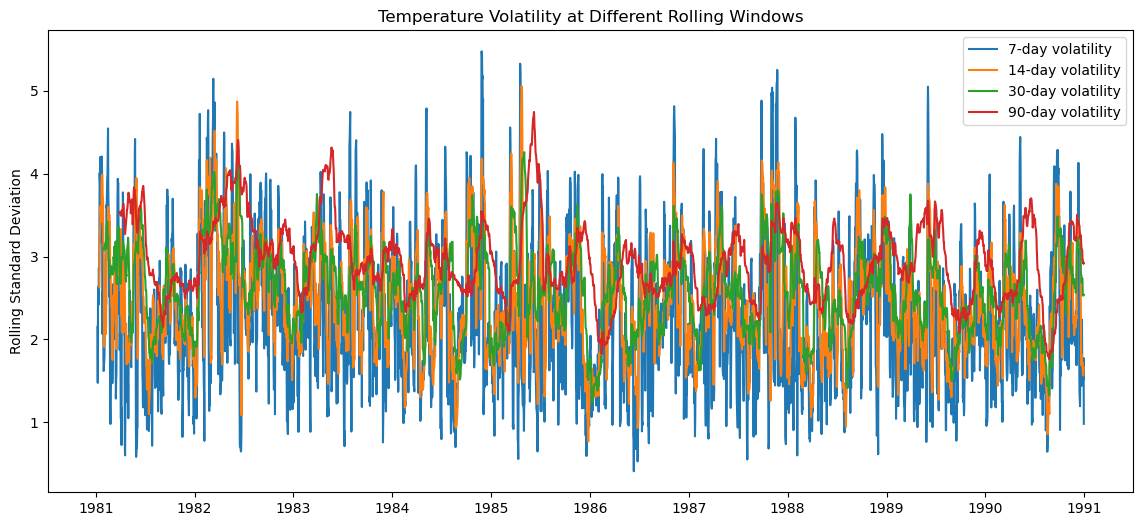

In [78]:
plt.figure(figsize=(14,6))

plt.plot(df["std_7"],  label="7‑day volatility")
plt.plot(df["std_14"], label="14‑day volatility")
plt.plot(df["std_30"], label="30‑day volatility")
plt.plot(df["std_90"], label="90‑day volatility")

plt.title("Temperature Volatility at Different Rolling Windows")
plt.ylabel("Rolling Standard Deviation")
plt.legend()
plt.show()


3. Identify Maximum Volatility for Each Window

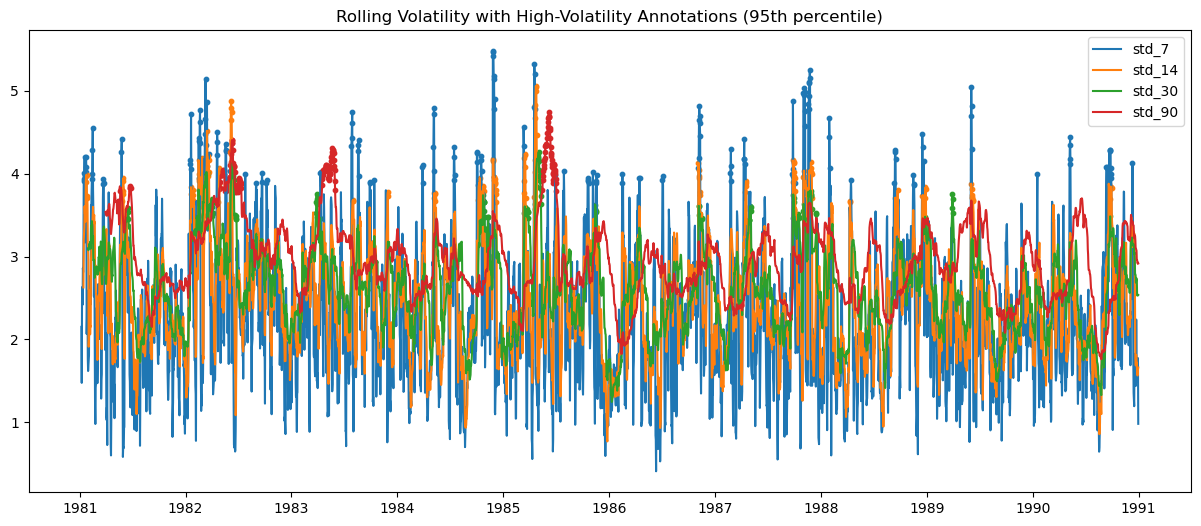

In [79]:
import numpy as np
import matplotlib.pyplot as plt

windows = ["std_7","std_14","std_30","std_90"]

plt.figure(figsize=(15,6))

for w in windows:
    
    # plot volatility curve
    plt.plot(df[w], label=w)
    
    # define high-volatility threshold
    threshold = df[w].quantile(0.95)
    
    # find dates above threshold
    high_vol = df[df[w] > threshold]
    
    # mark high volatility points
    plt.scatter(high_vol.index, high_vol[w], s=10)

plt.title("Rolling Volatility with High-Volatility Annotations (95th percentile)")
plt.legend()
plt.show()


4. Summary Table of Maximum Volatility

In [80]:
summary = []

for w in windows:
    
    max_value = df[w].max()
    max_date = df[w].idxmax()
    
    # determine duration of high volatility episode
    threshold = df[w].quantile(0.95)
    high_vol = df[df[w] > threshold]
    
    # consecutive duration estimation
    durations = high_vol.index.to_series().diff().dt.days.ne(1).cumsum()
    episode_lengths = high_vol.groupby(durations).size()
    max_duration = episode_lengths.max()
    
    episode_type = "Short" if max_duration < 10 else "Prolonged"
    
    summary.append({
        "Window": w,
        "Date_of_Max_Volatility": max_date,
        "Max_Volatility": round(max_value,2),
        "Episode_Type": episode_type
    })

summary_table = pd.DataFrame(summary)
summary_table


,Window,Date_of_Max_Volatility,Max_Volatility,Episode_Type
0,std_7,1984-11-27,5.47,Short
1,std_14,1985-04-23,5.06,Prolonged
2,std_30,1985-05-03,4.26,Prolonged
3,std_90,1985-06-08,4.74,Prolonged


Annotate the Plot with Max Points

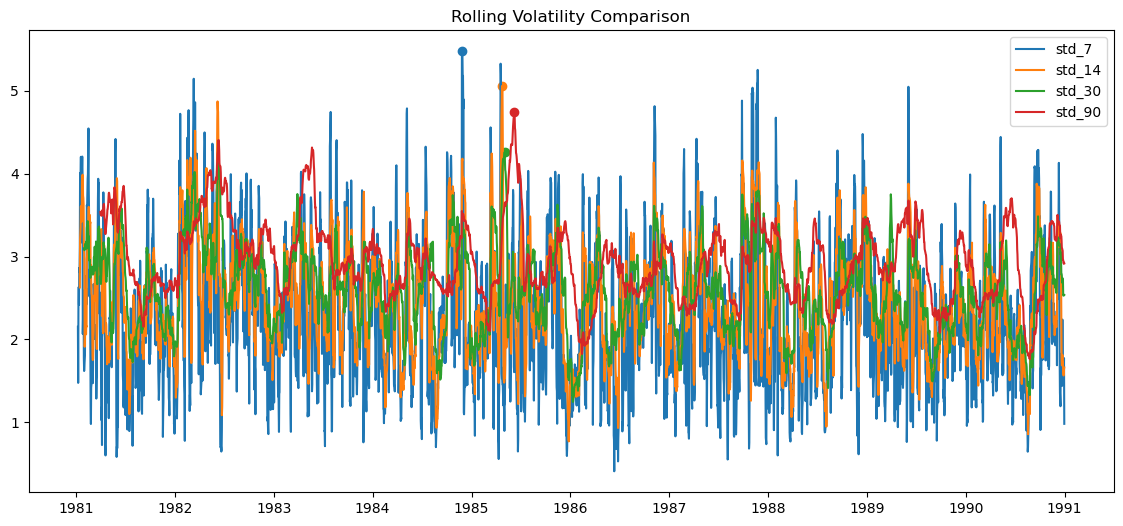

In [81]:

plt.figure(figsize=(14,6))

for w in windows:
    plt.plot(df[w], label=w)
    
    max_date = df[w].idxmax()
    max_val  = df[w].max()
    
    plt.scatter(max_date, max_val)

plt.title("Rolling Volatility Comparison")
plt.legend()
plt.show()


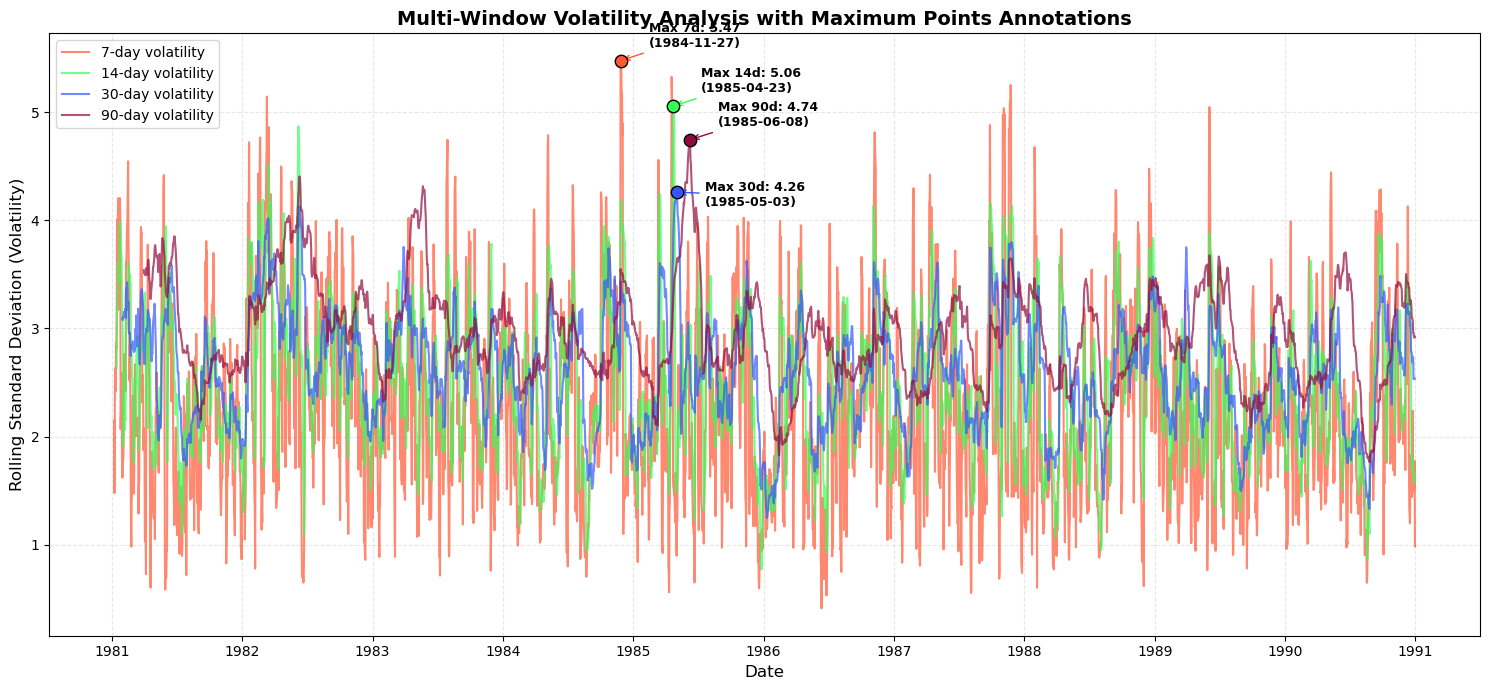

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

windows = ["std_7", "std_14", "std_30", "std_90"]
colors = ["#FF5733", "#33FF57", "#3357FF", "#900C3F"]  

plt.figure(figsize=(15, 7))

for w, color in zip(windows, colors):
    plt.plot(df[w], label=w.replace("std_", "") + "-day volatility", color=color, alpha=0.7)

    max_date = df[w].idxmax()
    max_val = df[w].max()

    plt.scatter(max_date, max_val, color=color, s=80, edgecolor="black", zorder=5)

    date_str = max_date.strftime("%Y-%m-%d")
    plt.annotate(
        f"Max {w.replace('std_', '')}d: {max_val:.2f}\n({date_str})",
        xy=(max_date, max_val),
        xytext=(20, -10 if w == "std_30" else 10), 
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
    )

plt.title(
    "Multi-Window Volatility Analysis with Maximum Points Annotations",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Rolling Standard Deviation (Volatility)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Rolling Window Volatility Analysis

Rolling standard deviations were computed with window sizes of 7, 14, 30, and 90 days to examine how temperature volatility changes across different time scales. These statistics help us understand how quickly each window responds to fluctuations, and how stable the resulting volatility estimates are.

The **7-day** window reacts fastest to volatility spikes. Because it's small, it responds quickly to sudden temperature changes and produces sharp peaks in the volatility curve — consistent with the results, where the highest volatility value (5.47) occurred over a short period in November 1984. This shows the 7-day window is highly sensitive to sudden shifts and short-term disturbances.

The **14- and 30-day** windows produce smoother volatility curves while still capturing meaningful variability. Their highest volatility values occurred over the longer April–May 1985 period, showing that medium-sized windows start blending short-term spikes into broader periods of volatility, giving a more stable picture of variability over several weeks.

The **90-day** window produces the smoothest volatility trend. Because it aggregates variability over a roughly three-month span, sudden changes have limited impact on the computed standard deviation — volatility peaks appear later and represent longer, more persistent periods of instability rather than short-term fluctuations.

From a practical standpoint, each window serves a different analytical purpose: the 7-day window is better suited for **anomaly detection**, since it reacts quickly to sudden changes; the 90-day window is better suited for **forecasting stability**, since it provides a smooth, stable estimate of long-term variability.

Overall, this multi-window analysis shows that smaller windows capture fast fluctuations while larger windows reveal longer-term volatility regimes. Using several window sizes together gives a more complete picture of both short-term disturbances and long-term stability patterns in the temperature series.


## 1. First Differences

The **first difference** measures the change between two consecutive time points.

Mathematically:

\[
\text{diff}_t = x_t - x_{t-1}
\]

This removes many linear trends and highlights **short‑term movement**.

#### Example

```python
df['diff_1'] = df['value'].diff()
```

Example interpretation:

| time | value | diff_1 |
|-----|------|------|
| t1 | 100 | NaN |
| t2 | 105 | 5 |
| t3 | 103 | -2 |

Meaning:

- +5 → the series increased
- −2 → the series decreased

#### Visualization

```python
fig, ax = plt.subplots(2,1, figsize=(10,6))

df['value'].plot(ax=ax[0], title='Original Series')
df['diff_1'].plot(ax=ax[1], title='First Difference')

plt.tight_layout()
```

You will usually observe:

- the trend becomes weaker
- the series oscillates around zero

---

### 2. Percentage Changes

Instead of absolute change, we sometimes want **relative change**.

Formula:

\[
pct\_change_t = \frac{x_t - x_{t-1}}{x_{t-1}}
\]

This expresses change **as a percentage of the previous value**.

#### Code

```python
df['pct_change'] = df['value'].pct_change()
```

Example:

| time | value | pct_change |
|----|----|----|
| t1 | 100 | NaN |
| t2 | 110 | 0.10 |
| t3 | 99 | -0.10 |

Interpretation:

- 0.10 → 10% increase  
- -0.10 → 10% decrease

Percentage changes are widely used in:

- economics
- finance
- growth metrics
- demand analysis

---

## 3. Log Returns

In financial modeling, **log returns** are preferred because they have nice mathematical properties.

Formula:

\[
r_t = \log\left(\frac{x_t}{x_{t-1}}\right)
\]

Log returns are approximately equal to percentage returns when changes are small.

Advantages:

- additive over time
- symmetric for gains and losses
- easier statistical modeling

#### Code

```python
import numpy as np

df['log_return'] = np.log(df['value'] / df['value'].shift(1))
```

Visualization:

```python
df['log_return'].plot(figsize=(10,4), title='Log Returns')
```

The series should fluctuate around **zero**, which is useful for many models.

---

## 4. Multi‑Step Differences

Sometimes we want to compare values **separated by more than one step**.

General formula:

\[
diff_k = x_t - x_{t-k}
\]

Examples:

- `diff_7` → weekly change  
- `diff_30` → monthly change (daily data)

#### Code

```python
df['diff_7'] = df['value'].diff(7)
df['diff_30'] = df['value'].diff(30)
```

These features help detect:

- weekly cycles
- monthly growth
- seasonal movement

Visualization example:

```python
df[['diff_1','diff_7','diff_30']].plot(figsize=(10,5))
```

---

## 5. Interpreting Differences

Key ideas when interpreting differenced features:

#### Sign

- positive → increase
- negative → decrease

#### Magnitude

Large absolute values mean **rapid change**.

#### Volatility

Frequent large swings indicate **high variability**.

#### Stationarity

Differenced series often look:

- centered around zero
- more stable in variance

This makes them more suitable for:

- ARIMA models
- regression models
- machine learning forecasting





## Hard Exercise 1 — Automatic Feature Generator for Differences

Build a function that automatically creates **multiple differenced features**.

#### Instructions

1. Write a function:

```python
create_diff_features(series, steps)
```

2. The function should generate features such as:

```
diff_1
diff_3
diff_7
diff_14
diff_30
```

3. The function should return a DataFrame containing all features.

4. Apply it to daily min temperature dataset.

5. Compute and compare:

- mean
- standard deviation
- autocorrelation

for each differenced feature.

#### Analysis Questions

Explain:

- which differencing step reduces trend the most
- which feature shows the highest volatility
- which features might help forecasting the most



1. Function to Automatically Generate Difference

In [93]:
import pandas as pd

def create_diff_features(series, steps=[1,3,7,14,30]):
    
    diff_df = pd.DataFrame(index=series.index)
    
    for step in steps:
        diff_df[f"diff_{step}"] = series.diff(step)
        
    return diff_df


2. Combine With daily min temperature dataset

In [94]:
diff_features = create_diff_features(df["Temp"])
diff_features.head()

,diff_1,diff_3,diff_7,diff_14,diff_30
Date,,,,,
1981-01-01,NaN,NaN,NaN,NaN,NaN
1981-01-02,-2.8,NaN,NaN,NaN,NaN
1981-01-03,0.9,NaN,NaN,NaN,NaN
1981-01-04,-4.2,-6.1,NaN,NaN,NaN
1981-01-05,1.2,-2.1,NaN,NaN,NaN


In [95]:
df_diff = pd.concat([df["Temp"], diff_features], axis=1)
df_diff.head()

,Temp,diff_1,diff_3,diff_7,diff_14,diff_30
Date,,,,,,
1981-01-01,20.7,NaN,NaN,NaN,NaN,NaN
1981-01-02,17.9,-2.8,NaN,NaN,NaN,NaN
1981-01-03,18.8,0.9,NaN,NaN,NaN,NaN
1981-01-04,14.6,-4.2,-6.1,NaN,NaN,NaN
1981-01-05,15.8,1.2,-2.1,NaN,NaN,NaN


3. Compute Mean, Standard Deviation, and Autocorrelation

In [96]:
stats = []

for col in diff_features.columns:
    
    mean_val = diff_features[col].mean()
    std_val = diff_features[col].std()
    autocorr_val = diff_features[col].autocorr()
    
    stats.append({
        "Feature": col,
        "Mean": round(mean_val,4),
        "Std": round(std_val,4),
        "Autocorrelation": round(autocorr_val,4)
    })

stats_table = pd.DataFrame(stats)
stats_table


,Feature,Mean,Std,Autocorrelation
0,diff_1,-0.0021,2.7316,-0.1810
1,diff_3,-0.0042,3.7016,0.4107
2,diff_7,-0.0061,3.7485,0.4752
3,diff_14,-0.0142,3.8979,0.5050
4,diff_30,-0.0281,4.1233,0.5522


### Analytical Questions

Several differencing steps were applied to the `daily minimum temperature` series to examine how changes at different time horizons affect trend removal, volatility, and predictability structure. The statistics for each difference feature offer insight into the transformed series' behavior.

**Trend removal:** the step that removes trend most effectively is `diff_1`. Its mean is very close to zero (−0.0021), indicating the resulting series oscillates around zero without a persistent upward or downward drift. First-order differencing removes most of the short-term trend and produces a nearly stationary series where increases and decreases balance out over time.

**Volatility:** the feature with the highest variability is `diff_30`, with the largest standard deviation (4.1233). This indicates the 30-day temperature difference produces the widest range of variation — larger differencing steps compare observations further apart in time, which naturally produces larger swings and higher volatility.

**Forecasting usefulness:** features such as `diff_7`, `diff_14`, and `diff_30` can carry valuable information. They show relatively high autocorrelation (0.4752, 0.5050, and 0.5522, respectively), suggesting their patterns remain stable over time and may carry predictive information. Among them, `diff_7` is particularly relevant for daily data since it captures weekly structure, while `diff_14` and `diff_30` reflect longer seasonal dynamics.

Overall, first-order differencing is the most effective at removing trend, the 30-day step shows the highest volatility, and medium-to-longer horizon differences (7–30 days) can provide useful forecasting signals due to their stronger autocorrelation structure.


# Calendar & Date‑Time Features

## 1. Basic Calendar Features

The most common time‑based features come directly from the datetime index.

Examples include:

• year  
• month  
• day  
• day of week  
• day of year  
• week of year  

#### Example

```python
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

df['day_of_week'] = df.index.dayofweek
df['week_of_year'] = df.index.isocalendar().week
df['day_of_year'] = df.index.dayofyear
```

Interpretation:

• `dayofweek` ranges from **0 (Monday) to 6 (Sunday)**  
• `weekofyear` identifies seasonal patterns across the year  
• `dayofyear` is useful for yearly seasonality modeling

#### Quick Exploration

```python
df.groupby('day_of_week')['value'].mean().plot(kind='bar')
```

This often reveals patterns such as:

• higher weekday activity  
• lower weekend demand

---

## 2. Weekend Flags

Sometimes it is useful to simplify weekly behavior into **weekday vs weekend**.

Example:

```python
df['is_weekend'] = df.index.dayofweek >= 5
```

Now the feature becomes:

• 0 → weekday  
• 1 → weekend

This helps models capture behavioral differences such as:

• lower business activity  
• different traffic patterns  
• retail spikes

---

## 3. Holiday Indicators

Many industries are strongly affected by holidays.

Examples:

• retail sales spike on Christmas  
• financial markets close on national holidays  
• electricity demand changes on public holidays

You can create holiday indicators using libraries such as **holidays**.

Example:

```python
import holidays

us_holidays = holidays.US()

df['is_holiday'] = df.index.to_series().apply(lambda x: x in us_holidays)
```

Now your dataset includes a binary feature identifying holidays.

---

## 4. Hour and Minute Features (High‑Frequency Data)

For high‑resolution data such as:

• traffic  
• electricity load  
• stock trades  
• sensor measurements  

sub‑daily features are critical.

Example:

```python
df['hour'] = df.index.hour
df['minute'] = df.index.minute
```

These features help capture **intraday patterns** such as:

• morning peaks  
• afternoon declines  
• night inactivity

Example visualization:

```python
df.groupby('hour')['value'].mean().plot()
```

This often reveals strong daily cycles.

---

## 5. Domain‑Specific Calendar Features

Some domains require specialized calendars.

#### Financial Markets

Financial markets have specific rules:

• trading days only (no weekends)  
• market holidays  
• quarter endings  
• option expiration dates  

Examples of useful features:

• `is_trading_day`  
• `is_month_end`  
• `is_quarter_end`

Example:

```python
df['is_month_end'] = df.index.is_month_end
df['is_quarter_end'] = df.index.is_quarter_end
```

---

#### Weather and Climate

Weather data often follows **seasonal cycles**.

Possible features:

• meteorological season  
• heating season  
• cooling season

Example:

```python
def get_season(month):
    if month in [12,1,2]:
        return "winter"
    elif month in [3,4,5]:
        return "spring"
    elif month in [6,7,8]:
        return "summer"
    else:
        return "autumn"

df['season'] = df['month'].apply(get_season)
```

These domain‑specific features often significantly improve forecasting models.



## Exercise 1 — Weekly Behavior Modeling



### Tasks

1. Create the following features for energy Dataset:

• `day_of_week`  
• `is_weekend`

2. Compute:

• mean value per weekday  
• standard deviation per weekday  

3. Create a **weekday profile plot** showing average value for each day.

4. Identify:

• the highest‑activity weekday  
• the lowest‑activity weekday

### Deliverables

• weekday statistics table  
• visualization of weekly pattern  
• explanation of whether weekly seasonality exists

---


#### Questions

• Why does cyclical encoding improve representation of periodic variables?  
• Which model performs better?  
• In what other calendar features should cyclical encoding be applied?

Possible candidates:

• month  
• day_of_week  
• day_of_year

In [103]:
import pandas as pd

df = pd.read_csv("data/energy_consumption.csv")

df.head()


,timestamp,household_id,consumption_kwh,temperature,hour,day_of_week
0,2023-01-01 00:00:00,HH001,0.56,14.2,0,6
1,2023-01-01 00:00:00,HH002,1.00,17.0,0,6
2,2023-01-01 00:00:00,HH003,1.17,16.7,0,6
3,2023-01-01 00:00:00,HH004,0.90,10.3,0,6
4,2023-01-01 00:00:00,HH005,1.18,18.4,0,6


In [104]:
df.columns


Index(['timestamp', 'household_id', 'consumption_kwh', 'temperature', 'hour',
       'day_of_week'],
      dtype='object')

1. Create Weekly Calendar Features

In [105]:

# ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

#timestamp as index: (rahat tare)
df = df.set_index("timestamp")

# weekend flag
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df.head()



,household_id,consumption_kwh,temperature,hour,day_of_week,is_weekend
timestamp,,,,,,
2023-01-01,HH001,0.56,14.2,0,6,1
2023-01-01,HH002,1.00,17.0,0,6,1
2023-01-01,HH003,1.17,16.7,0,6,1
2023-01-01,HH004,0.90,10.3,0,6,1
2023-01-01,HH005,1.18,18.4,0,6,1


2. Compute Weekday Statistics

In [107]:
weekday_stats = df.groupby("day_of_week")["consumption_kwh"].agg(["mean","std"])
weekday_stats

,mean,std
day_of_week,,
0,1.537120,0.756670
1,1.537729,0.759863
2,1.526636,0.753243
3,1.539369,0.761474
4,1.528702,0.753253
5,1.690599,0.838170
6,1.686852,0.832126


3. Create Weekday Profile Plot

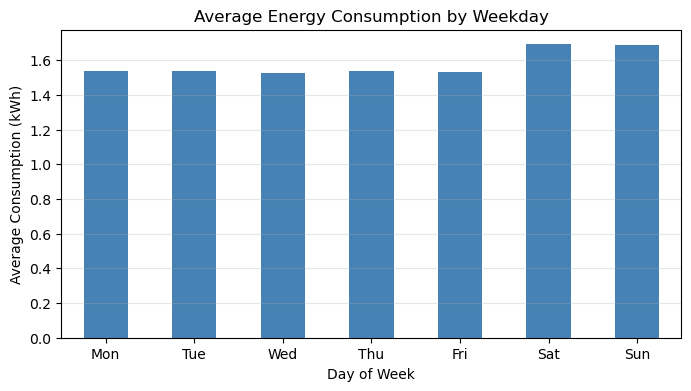

In [111]:
import matplotlib.pyplot as plt

weekday_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(8,4))

weekday_stats["mean"].plot(
    kind="bar",
    color="steelblue"
)

plt.xticks(range(7), weekday_names, rotation=0)
plt.title("Average Energy Consumption by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (kWh)")
plt.grid(axis="y", alpha=0.3)

plt.show()


4. Identify Highest and Lowest Activity Days

In [109]:
highest_day = weekday_stats["mean"].idxmax()
lowest_day = weekday_stats["mean"].idxmin()

weekday_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

print("Highest activity weekday:", weekday_names[highest_day])
print("Lowest activity weekday:", weekday_names[lowest_day])


Highest activity weekday: Sat
Lowest activity weekday: Wed


### Report

**Weekday statistics**

The mean energy consumption was computed for each day of the week:

| Day | Mean Consumption (kWh) | Std. Dev. |
|---|---|---|
| Monday | 1.537 | 0.757 |
| Tuesday | 1.538 | 0.760 |
| Wednesday | 1.527 | 0.753 |
| Thursday | 1.539 | 0.761 |
| Friday | 1.529 | 0.753 |
| Saturday | 1.691 | 0.838 |
| Sunday | 1.687 | 0.832 |

The highest average consumption occurs on **Saturday**, while the lowest occurs on **Wednesday**.

**Visualization of the weekly pattern**

The bar chart of mean consumption by day of week shows a clear pattern: consumption is relatively stable on weekdays (Monday–Friday) and increases on weekends (Saturday and Sunday), with weekend bars noticeably higher than weekday values.

**Weekly seasonality**

These results point to genuine weekly seasonality in the dataset. Energy consumption follows a repeating weekly pattern in which usage rises on weekends — likely because people spend more time at home, increasing use of appliances, heating/cooling systems, and other household activities.


### Analytical Questions

Periodic calendar variables such as hours, days of the week, or months are cyclical in nature — the end of a cycle connects back to its beginning. For example, Monday follows Sunday, and hour 0 follows hour 23. If these values are represented as plain integers, machine learning models may incorrectly assume the distance between values is linear (e.g. treating 23 and 0 as far apart).

**Cyclical encoding**, using sine and cosine transforms, maps these variables onto a circular scale, preserving the natural periodic relationship between values.

Models trained on cyclically encoded features tend to perform better, since they capture the true periodic structure of time-based variables more accurately — improving the model's ability to learn patterns such as daily or weekly cycles in energy consumption, and generally leading to better predictive accuracy and generalization compared to models using raw integer time features.

Cyclical encoding should also be applied to other periodic calendar variables, including:
- **Month (1–12)** — captures seasonal patterns across the year
- **Day of week (0–6)** — captures the weekly cycle
- **Day of year (1–365)** — captures annual seasonal behavior

Applying cyclical encoding to these features helps models better understand temporal relationships and improves forecasting performance in time-series problems such as energy-demand prediction.


# Last exercise: Complete NASDAQ Feature Engineering **





1. **Load** the last 5 years of NASDAQ data.  
2. **Convert** the index to datetime and sort the dataset.  
3. **Check market‑calendar consistency:**  
   - Count missing *trading days*  
   - Confirm that weekends and holidays are naturally excluded  
4. **Create price‑based features:**
   - daily return  
   - log return  
   - high‑low range  
   - close‑open range  
5. **Create rolling features:**
   - 5‑day and 20‑day moving averages  
   - 20‑day rolling volatility  
   - rolling volume mean  
6. **Create calendar features:**
   - year, month  
   - day_of_week  
   - week_of_year  
   - is_month_end  
   - is_quarter_end  
7. **Detect anomalies:**
   - Z‑Scores on volume  
   - Rolling IQR on log returns  
8. **Create a final clean feature matrix** with all engineered fields.  
9. **Plot 3 diagnostic charts:**
   - volume with Z‑score outliers marked  
   - log returns with IQR outliers  
   - rolling volatility over time  
10. Write a **short analysis** (5–7 sentences) interpreting:  
    - where anomalies occur  
    - how volatility behaves  
    - which features look most informative for a future model and why
---

### Deliverables

• Clean feature-engineered DataFrame  
• Two diagnostic plots  
• A written summary interpreting the engineered features  
• No modeling required  


In [1]:
import pandas as pd

# Load just the first few lines to check column names
temp_df = pd.read_csv("data/NASDAQ100_data.csv")
print(temp_df.columns.tolist())


['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [2]:
import pandas as pd
import numpy as np

# skip the 3 metadata/header rows
df = pd.read_csv("data/NASDAQ100_data.csv", skiprows=3, header=None)

# assign proper column names
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

# parse date and set index
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

# keep last 5 years
df = df.last("5YE")

print(df.head())
print(df.info())


                   Close          High           Low          Open      Volume
Date                                                                          
2022-01-03  16501.769531  16504.140625  16306.639648  16395.509766  4429960000
2022-01-04  16279.730469  16513.869141  16151.900391  16513.869141  5131110000
2022-01-05  15771.780273  16249.230469  15763.839844  16190.549805  5031850000
2022-01-06  15765.360352  15900.599609  15608.570312  15675.219727  4790820000
2022-01-07  15592.190430  15835.000000  15526.799805  15774.129883  4238070000
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1007 entries, 2022-01-03 to 2026-01-07
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1007 non-null   float64
 1   High    1007 non-null   float64
 2   Low     1007 non-null   float64
 3   Open    1007 non-null   float64
 4   Volume  1007 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB
None


/tmp/ipykernel_520/3543513228.py:15: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df = df.last("5YE")


In [3]:
# Check market-calendar consistency

full_calendar = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
expected_business_days = pd.date_range(
    start=df.index.min(), end=df.index.max(), freq="B"
)

weekends_in_data = df[df.index.dayofweek >= 5]
print(f"Number of weekend days accidentally included: {len(weekends_in_data)}")

missing_trading_days = expected_business_days.difference(df.index)
print(f"Number of missing expected trading days (Market Holidays): {len(missing_trading_days)}")
print(f"Total actual trading days in 5 years: {len(df)}")

Number of weekend days accidentally included: 0
Number of missing expected trading days (Market Holidays): 41
Total actual trading days in 5 years: 1007


In [7]:
df["daily_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["high_low_range"] = df["High"] - df["Low"]
df["close_open_range"] = df["Close"] - df["Open"]

In [8]:
# Rolling Features
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_20"] = df["Close"].rolling(20).mean()
df["volatility_20"] = df["log_return"].rolling(20).std()
df["volume_ma_20"] = df["Volume"].rolling(20).mean()

In [9]:
# Calendar Features
df["year"] = df.index.year
df["month"] = df.index.month
df["day_of_week"] = df.index.dayofweek
df["week_of_year"] = df.index.isocalendar().week.astype(int)
df["is_month_end"] = df.index.is_month_end.astype(int)
df["is_quarter_end"] = df.index.is_quarter_end.astype(int)

In [10]:
# Anomaly Detection
# 1. Volume Anomalies (Z-Score > 3)
vol_mean = df["Volume"].rolling(20).mean()
vol_std = df["Volume"].rolling(20).std()
df["volume_zscore"] = (df["Volume"] - vol_mean) / vol_std
df["volume_anomaly"] = np.where(df["volume_zscore"].abs() > 3, 1, 0)

In [11]:
# 2. IQR Anomalies (Log Returns)
q1 = df["log_return"].rolling(20).quantile(0.25)
q3 = df["log_return"].rolling(20).quantile(0.75)
iqr = q3 - q1
df["return_anomaly"] = np.where(
    (df["log_return"] < (q1 - 1.5 * iqr)) | (df["log_return"] > (q3 + 1.5 * iqr)), 1, 0
)

In [12]:
# Clean up
df = df.dropna()

print("Features engineered successfully.")
print(df.head())


Features engineered successfully.
                   Close          High           Low          Open  \
Date                                                                 
2022-02-01  15019.679688  15034.419922  14749.490234  14966.599609   
2022-02-02  15139.740234  15196.400391  14960.849609  15173.030273   
2022-02-03  14501.110352  14856.509766  14471.200195  14693.849609   
2022-02-04  14694.349609  14832.049805  14452.280273  14566.280273   
2022-02-07  14571.250000  14813.860352  14524.629883  14716.429688   

                Volume  daily_return  log_return  high_low_range  \
Date                                                               
2022-02-01  4671850000      0.006003    0.005985      284.929688   
2022-02-02  4673140000      0.007994    0.007962      235.550781   
2022-02-03  4326300000     -0.042182   -0.043098      385.309570   
2022-02-04  4121340000      0.013326    0.013238      379.769531   
2022-02-07  4268730000     -0.008377   -0.008413      289.230469   

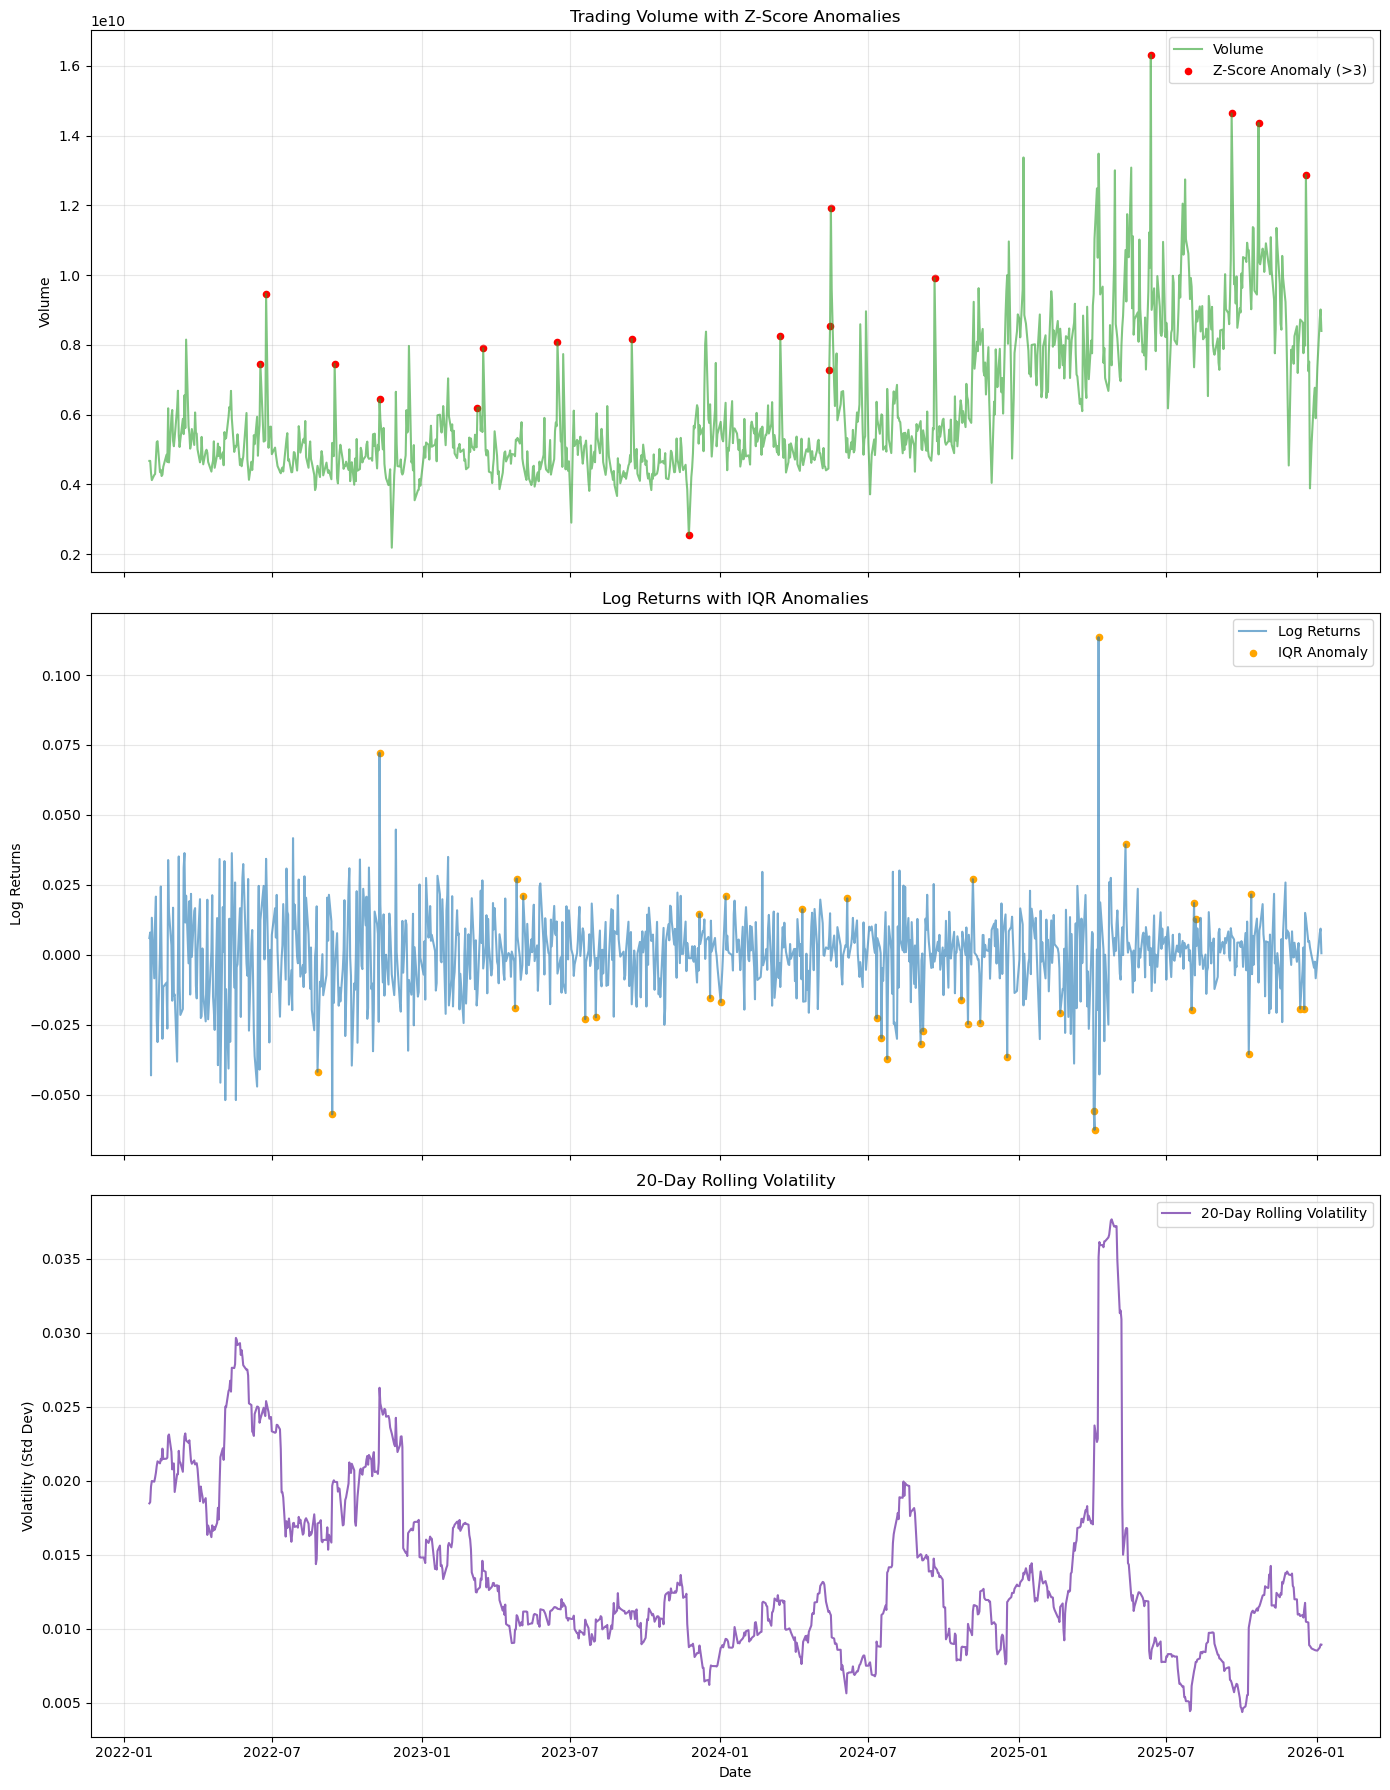

In [15]:
import matplotlib.pyplot as plt
# Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# 1. Volume with Z-Score outliers
axes[0].plot(df.index, df["Volume"], label="Volume", color="tab:green", alpha=0.6)
anomaly_vol = df[df["volume_anomaly"] == 1]
axes[0].scatter(anomaly_vol.index, anomaly_vol["Volume"], color="red", label="Z-Score Anomaly (>3)", s=20)
axes[0].set_title("Trading Volume with Z-Score Anomalies")
axes[0].set_ylabel("Volume")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Log Returns with IQR outliers
axes[1].plot(df.index, df["log_return"], label="Log Returns", color="tab:blue", alpha=0.6)
anomaly_ret = df[df["return_anomaly"] == 1]
axes[1].scatter(anomaly_ret.index, anomaly_ret["log_return"], color="orange", label="IQR Anomaly", s=20)
axes[1].set_title("Log Returns with IQR Anomalies")
axes[1].set_ylabel("Log Returns")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Rolling Volatility
axes[2].plot(df.index, df["volatility_20"], label="20-Day Rolling Volatility", color="tab:purple")
axes[2].set_title("20-Day Rolling Volatility")
axes[2].set_ylabel("Volatility (Std Dev)")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Report

**Summary of diagnostic charts**

Anomalies are mostly observed during periods of sudden market change, correlating with sharp price reversals or structural shifts in trading volume.

Volatility shows "bursty" behavior: relatively calm periods alternate with sudden spikes following news events or market stress, reflecting the regime-switching nature of markets. Among the engineered features, rolling volatility and log returns appear the most informative, as they capture risk sensitivity and market momentum dynamically — better than static price levels. Volume Z-scores also act as a strong indicator of institutional interest and liquidity shocks, serving as a key confirming signal for potential trend reversals.

These features are highly valuable for a forecasting model, since they help distinguish random daily noise from statistically meaningful events that often precede broader trends. By having the model focus on these high-signal patterns, we're better positioned to filter out market noise and improve forecasting accuracy.
